# Проект по временным рядам 
# Выполнил: Крамин Мурат Тимурович, ФТиАД, 1 курс

# **ПЛАН ПРОЕКТА**

## **Блок 0. Подготовка данных**  

##  **Блок 1. Генерация признаков для ML** 

##  **Блок 2. Анализ временного ряда `balance` (для ARIMA/SARIMA)** 


##  **Блок 3. Построение авторегрессионных моделей** 


##  **Блок 4. `tsfresh` как обогащение признаков** 



## **Блок 5. Отбор признаков (FS) для ML** 



## **Блок 6. Построение ML моделей** 



## **Блок 7. Обнаружение разладок (CUSUM)** 


##  **Блок 8. Онлайн и Автоматическое переобучение** 


---



# Блок 0. Подготовка данных


In [21]:
#Установим библиотеки
%pip install pandas matplotlib openpyxl requests tqdm beautifulsoup4 yfinance scikit-learn seaborn statsmodels pmdarima tsfresh catboost lightgbm optuna bayesian-changepoint-detection

  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/5e/23/f8b28ca248bb629b9e08f877dd2965d1994e1674a03d67cd10c5246da248/lightgbm-4.6.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   - -------------------------------------- 0.1/1.5 MB 1.1 MB/s eta 0:00:02
   ----- ---------------------------------- 0.2/1.5 MB 1.8 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.5 MB 3.3 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.5 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Извелекаем данные из exel файла

In [34]:
import pandas as pd

# Путь к файлу
excel_file = 'Project 2_2023.xlsx'

# Загрузка данных с листа "Data"
df = pd.read_excel(excel_file, sheet_name='Data')

# Преобразование даты к формату 'YYYY-MM-DD'
df['Date'] = pd.to_datetime(df['Date']).dt.date
# Преобразование всех названий столбцов в lowercase
df.columns = df.columns.str.lower()

# Удаление старой колонки balance (если она есть)
if 'balance' in df.columns:
    df = df.drop(columns=['balance'])

# Создание новой колонки balance как разности income и outcome
df['balance'] = df['income'] - df['outcome']

# Сохранение в CSV
df.to_csv('data/saldo.csv', index=False, encoding='utf-8')


### Парсим и сохраняем нерабочие дни из производственного календаря

In [ ]:
import pandas as pd
import datetime
from io import StringIO
import requests

# Диапазон годов
years = range(2016, 2025)

# Список для хранения всех выходных и праздничных дней
holiday_dates = []

# Загружаем календари и собираем выходные
for year in years:
    url = f"https://xmlcalendar.ru/data/ru/{year}/calendar.csv"
    response = requests.get(url)
    response.encoding = 'utf-8'
    df = pd.read_csv(StringIO(response.text))
    
    for idx, row in df.iterrows():
        year_val = int(row['Год/Месяц'])
        for month_num, month_name in enumerate(df.columns[1:13]):
            if pd.isna(row[month_name]):
                continue
            days = str(row[month_name]).split(',')
            for day in days:
                day_clean = day.replace('*', '').replace('+', '')
                if day_clean.isdigit():
                    date = datetime.date(year_val, month_num + 1, int(day_clean))
                    holiday_dates.append(date)

# Создание DataFrame с полным списком дат
full_dates = pd.date_range(start='2016-01-01', end='2024-12-31', freq='D')
calendar_df = pd.DataFrame({'date': full_dates})

# Помечаем нерабочие дни: 1 — нерабочий, 0 — рабочий
calendar_df['is_non_working_day'] = calendar_df['date'].dt.date.isin(holiday_dates).astype(int)

# Сохраняем в CSV
calendar_df.to_csv('data/non_working_days.csv', index=False, encoding='utf-8')


### Парсим и сохраняем ключевую ставку с сайта ЦБ

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from datetime import datetime

# URL страницы с таблицей
url = 'https://www.cbr.ru/hd_base/KeyRate/?UniDbQuery.Posted=True&UniDbQuery.From=01.01.2016&UniDbQuery.To=17.04.2025'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'
}

# Отправка запроса
response = requests.get(url, headers=headers)
response.encoding = 'utf-8'

# Парсинг HTML
soup = BeautifulSoup(response.text, 'html.parser')
table = soup.find('table', class_='data')
rows = table.find_all('tr')

# Сбор данных
data = []
for row in rows[1:]:  # Пропускаем заголовок
    cols = row.find_all('td')
    if len(cols) == 2:
        date_str = cols[0].text.strip()
        rate_str = cols[1].text.strip().replace(',', '.')
        try:
            date = datetime.strptime(date_str, '%d.%m.%Y').strftime('%Y-%m-%d')
            rate = float(rate_str)
            data.append([date, rate])
        except ValueError:
            continue

# Создание DataFrame
df = pd.DataFrame(data, columns=['date', 'rate'])

# Преобразуем 'date' в datetime и задаём индекс
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# Создание полного диапазона дат
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

# Заполнение пропущенных дат и перенос последнего значения
df_full = df.reindex(full_range).ffill()

# Сброс индекса и переименование столбца обратно в 'date'
df_full = df_full.reset_index().rename(columns={'index': 'date'})

# Сохранение в CSV
df_full.to_csv('data/key_rate.csv', index=False, encoding='utf-8')

print("Данные сохранены в data/key_rate.csv")


### Парсим и сохраняем курс рубля к доллару

In [ ]:
import pandas as pd
import requests
import xml.etree.ElementTree as ET
from tqdm import tqdm
from datetime import datetime, timedelta

def get_usd_rub_cbr(date: datetime):
    url = f"https://www.cbr.ru/scripts/XML_daily.asp?date_req={date.strftime('%d/%m/%Y')}"
    response = requests.get(url)
    root = ET.fromstring(response.content)
    
    for valute in root.findall("Valute"):
        if valute.attrib["ID"] == "R01235":  # USD
            value = valute.find("Value").text
            return float(value.replace(",", "."))
    return None

# Диапазон дат
start_date = datetime(2016, 1, 1)
end_date = datetime(2024, 12, 31)
dates = pd.date_range(start=start_date, end=end_date, freq="D")

# Сбор курсов
records = []
for date in tqdm(dates, desc="Загрузка курсов ЦБ РФ"):
    rate = get_usd_rub_cbr(date)
    records.append({"date": date, "usd_rub": rate})

# DataFrame и сохранение
df = pd.DataFrame(records)
df["usd_rub"] = df["usd_rub"].ffill()  # Заполнение пропусков (выходные)
df["date"] = df["date"].dt.strftime("%Y-%m-%d")
df.to_csv("data/usd_rub_cbr.csv", index=False)
print(" Готово! Курс сохранён в data/usd_rub_cbr.csv")


### Скачиваем с сайта (https://investfunds.ru/indexes/224/) 
### и сохраняем курс золота (Банк России)

In [ ]:
import pandas as pd
from datetime import datetime

# Чтение Excel-файла
df = pd.read_excel("золото-(банк-россии)-(rub).xlsx")

# Переименование столбцов
df.columns = ['date', 'gold_cost_rub']

# Преобразование даты и стоимости
df['date'] = pd.to_datetime(df['date'], dayfirst=True).dt.strftime('%Y-%m-%d')
df['gold_cost_rub'] = df['gold_cost_rub'].astype(str).str.replace(' ', '').str.replace(',', '.').astype(float)

# Полный список дат
start_date = '2016-01-01'
end_date = '2024-12-31'
all_dates = pd.date_range(start=start_date, end=end_date, freq='D').strftime('%Y-%m-%d')
full_df = pd.DataFrame({'date': all_dates})

# Объединение и заполнение пропусков
merged_df = pd.merge(full_df, df, on='date', how='left')
merged_df['gold_cost_rub'] = merged_df['gold_cost_rub'].ffill()

# Сохранение в CSV
merged_df.to_csv('data/gold_price_full.csv', index=False, encoding='utf-8')

print(" Ежедневные данные по золоту сохранены в data/gold_price_full.csv")


### Парсим и сохраняем курс нефти Brent

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime

# Даты
start_date = datetime(2016, 1, 1)
end_date = datetime(2024, 12, 31)

# Скачиваем данные
oil_data = yf.download('BZ=F', start=start_date, end=end_date)
df = oil_data[['Close']].reset_index()
df.columns = ['date', 'brent_cost']
df['date'] = df['date'].dt.strftime('%Y-%m-%d')

# Создаём полный список дат
all_dates = pd.date_range(start=start_date, end=end_date, freq='D').strftime('%Y-%m-%d')
full_df = pd.DataFrame({'date': all_dates})

# Объединяем и заполняем пропуски
merged_df = pd.merge(full_df, df, on='date', how='left')
merged_df['brent_cost'] = merged_df['brent_cost'].ffill()

# Сохраняем в CSV
merged_df.to_csv('data/brent_oil_price.csv', index=False, encoding='utf-8')

print(" Ежедневные данные по нефти сохранены в data/brent_oil_price.csv")


### Парсим и сохраняем АРХИВ ЗНАЧЕНИЙ MOSPRIME

In [ ]:
import pandas as pd
import numpy as np
from io import StringIO
import requests

# Заданный диапазон дат
start_date = '2016-01-01'
end_date = '2024-12-31'

# URL для запроса
url = f"https://mosprime.com/archive?date_from={start_date}&date_to={end_date}&format=csv&contributor="

# Запрос и загрузка
response = requests.get(url)
response.encoding = 'cp1251'
content = response.text

# Пропускаем лишние строки до заголовка таблицы
lines = content.splitlines()
table_start_idx = next(i for i, line in enumerate(lines) if "Дата ставки" in line)
clean_csv = "\n".join(lines[table_start_idx:])

# Читаем CSV
df = pd.read_csv(StringIO(clean_csv), sep=";", engine='python')
df.rename(columns={"Дата ставки": "date"}, inplace=True)

# Преобразуем дату в datetime
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Обработка пропусков и преобразование в float
for col in df.columns[1:]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .replace({"--": np.nan, "-": np.nan,"–": np.nan, "": np.nan})
        .astype(float)
    )

# Удаляем лишние столбцы, полностью состоящие из NaN
df = df.dropna(axis=1, how='all')

# Устанавливаем индекс и создаём полный диапазон
df = df.set_index("date").sort_index()
full_range = pd.date_range(start=start_date, end=end_date, freq='D')
df = df.reindex(full_range).ffill()

# Сброс индекса обратно в 'date'
df = df.reset_index().rename(columns={"index": "date"})

# Сохранение
df.to_csv("data/mosprime_rates.csv", index=False, encoding="utf-8")

print(" MOSPRIME ставки сохранены в data/mosprime_rates.csv с полным диапазоном дат и ffill()")


### Используя нерабочие дни и другие календарные фичи создаём расширенный датасет календарных фич

In [ ]:
import pandas as pd
import numpy as np
import datetime

# Загрузка файла с нерабочими днями
calendar_df = pd.read_csv('data/non_working_days.csv')
calendar_df['date'] = pd.to_datetime(calendar_df['date'])

# Создание базового календарного DataFrame
start_date = calendar_df['date'].min()
end_date = calendar_df['date'].max()
full_dates = pd.date_range(start=start_date, end=end_date, freq='D')
features = pd.DataFrame(index=full_dates)
features.index.name = 'date'

# Признак: нерабочий день
calendar_df.set_index('date', inplace=True)
features['is_non_working_day'] = calendar_df['is_non_working_day'].reindex(features.index, fill_value=0)

# Признаки: день недели (английские названия)
for day in features.index.day_name().unique():
    features[f'day_{day}'] = (features.index.day_name() == day).astype(int)

# Признаки: месяц (английские названия)
for month in features.index.month_name().unique():
    features[f'month_{month}'] = (features.index.month_name() == month).astype(int)

# Признаки: начало и конец месяца
features['is_start_of_month'] = features.index.is_month_start.astype(int)
features['is_end_of_month'] = features.index.is_month_end.astype(int)

# Признак: последний день месяца
last_days = features.index.to_series().groupby([features.index.year, features.index.month]).max()
features['is_last_day_of_month'] = features.index.isin(last_days.values).astype(int)

# Признаки: годы
for year in features.index.year.unique():
    features[f'year_{year}'] = (features.index.year == year).astype(int)

# 🎯 Формальные признаки налоговых дат
features['tax_vat_payment_due'] = ((features.index.day == 20) & (features.index.month.isin([1, 4, 7, 10]))).astype(int)  # НДС
features['tax_income_payment_due'] = ((features.index.day == 20) & (features.index.month.isin([1, 2, 3, 4]))).astype(int)  # Прибыль
features['tax_unified_social_payment_due'] = ((features.index.day == 30) & (features.index.month == 4)).astype(int)  # ЕССС
features['tax_all_payment_due'] = ((features.index.day == 28)).astype(int)  # Условный all-tax
features['tax_annual_payment_due'] = ((features.index.day == 1) & (features.index.month == 12)).astype(int)  # Годовая уплата

# 🎉 Признаки фиксированных праздников (просто и читаемо)
fixed_holidays = {
    'New_Year': [(1, d) for d in range(1, 9)],
    'Defender_of_Fatherland_Day': [(2, 23)],
    'International_Womens_Day': [(3, 8)],
    'Labour_Day': [(5, 1)],
    'Victory_Day': [(5, 9)],
    'Russia_Day': [(6, 12)],
    'Unity_Day': [(11, 4)],
}

features['is_official_holiday'] = 0
for _, dates in fixed_holidays.items():
    for month, day in dates:
        features['is_official_holiday'] |= ((features.index.month == month) & (features.index.day == day)).astype(int)

# Признаки: особые дни конца декабря
for day in range(27, 32):
    features[f'is_december_{day}'] = ((features.index.month == 12) & (features.index.day == day)).astype(int)

# Признаки: предрабочий и послерабочий день
# features['is_pre_non_working_day'] = features['is_non_working_day'].shift(-1, fill_value=0)
# features['is_post_non_working_day'] = features['is_non_working_day'].shift(1, fill_value=0)

# Признаки: предпраздничный и послепраздничный день
features['is_pre_holiday'] = features['is_official_holiday'].shift(-1, fill_value=0)
features['is_post_holiday'] = features['is_official_holiday'].shift(1, fill_value=0)

# Сброс индекса и сохранение
features.reset_index(inplace=True)
features.to_csv('data/calendar_features_full.csv', index=False, encoding='utf-8')

print(" Обновлённый календарь с фичами сохранён в 'data/calendar_features_full.csv'")


## Обоснование почему были добавлены именно такие фичи:

### Объединяем все полученные данные в один датасет

In [35]:
import pandas as pd

# Загрузка датасетов из папки data
saldo = pd.read_csv('data/saldo.csv', parse_dates=['date'])
calendar = pd.read_csv('data/calendar_features_full.csv', parse_dates=['date'])
brent = pd.read_csv('data/brent_oil_price.csv', parse_dates=['date'])
gold = pd.read_csv('data/gold_price_full.csv', parse_dates=['date'])
usd = pd.read_csv('data/usd_rub_cbr.csv', parse_dates=['date'])
key_rate = pd.read_csv('data/key_rate.csv', parse_dates=['date'])
mosprime = pd.read_csv('data/mosprime_rates.csv', parse_dates=['date'])

# Объединение всех таблиц по дате (left join от saldo)
df = saldo.merge(calendar, on='date', how='left')
df = df.merge(brent, on='date', how='left')
df = df.merge(gold, on='date', how='left')
df = df.merge(usd, on='date', how='left')
df = df.merge(key_rate, on='date', how='left')
df = df.merge(mosprime, on='date', how='left')

# Просмотр первых строк
print(df.head())

# Сохранение объединённого датасета
df.to_csv('data/merged_dataset.csv', index=False)


        date    income   outcome   balance  is_non_working_day  day_Friday  \
0 2017-01-09  1.343028  1.487865 -0.144836                   0           0   
1 2017-01-10  1.068610  1.194182 -0.125572                   0           0   
2 2017-01-11  0.944429  0.936663  0.007767                   0           0   
3 2017-01-12  1.672202  0.875379  0.796823                   0           0   
4 2017-01-13  0.955924  0.975645 -0.019721                   0           1   

   day_Saturday  day_Sunday  day_Monday  day_Tuesday  ...  gold_cost_rub  \
0             0           0           1            0  ...        2260.43   
1             0           0           0            1  ...        2264.82   
2             0           0           0            0  ...        2280.67   
3             0           0           0            0  ...        2297.00   
4             0           0           0            0  ...        2308.20   

   usd_rub  rate     ON     1W     2W     1M     2M     3M     6M  
0  60.

# **Блок 1. Генерация признаков для ML**

### Добавим в объединённый датасет лаги и скользящие различного рода

In [36]:
import pandas as pd

df = pd.read_csv('data/merged_dataset.csv', parse_dates=['date'])
df = df.sort_values('date').set_index('date')

target_columns = [
    'balance', 'income', 'outcome', 'brent_cost', 'gold_cost_rub',
    'usd_rub', 'rate', 'ON', '1W', '2W', '1M', '2M', '3M', '6M'
]

lags = [1, 2, 3]
rolling_windows = [3, 7]

lag_features = []
rolling_features = []

# Создаем лаги
for col in target_columns:
    for lag in lags:
        lag_features.append(df[col].shift(lag).rename(f'{col}_lag{lag}'))

# Создаем rolling с shift(1)
for col in target_columns:
    shifted = df[col].shift(1)
    for window in rolling_windows:
        rolling_features.append(shifted.rolling(window).mean().rename(f'{col}_rollmean{window}'))
        rolling_features.append(shifted.rolling(window).std().rename(f'{col}_rollstd{window}'))
        rolling_features.append(shifted.rolling(window).min().rename(f'{col}_rollmin{window}'))
        rolling_features.append(shifted.rolling(window).max().rename(f'{col}_rollmax{window}'))
        rolling_features.append(shifted.rolling(window).median().rename(f'{col}_rollmed{window}'))

# Объединяем всё за один раз — это быстро
new_features = pd.concat(lag_features + rolling_features, axis=1)

# Добавляем к исходному фрейму
df_final = pd.concat([df, new_features], axis=1).reset_index()

# Удаляем строки с NaN (на старте ряда)
df_final = df_final.dropna().reset_index(drop=True)


# Сохраняем без удаления NaN
df_final.to_csv('data/merged_dataset_with_lags_rollings.csv', index=False)
print(" Готово! Датасет с лагами и скользящими средними сохранён в 'data/merged_dataset_with_lags_rollings.csv'")


 Готово! Датасет с лагами и скользящими средними сохранён в 'data/merged_dataset_with_lags_rollings.csv'


## Почему были добавленны данные фичи обоснование:



# **Блок 1.2. Построение метрик для оценок моделей**

In [8]:
from sklearn.metrics import mean_absolute_error

def mae_cust(y_true, y_pred, key_rate):
    return mean_absolute_error(y_true, y_pred)

def calculate_add_margin_vectorized(y_true, y_pred, cbr_key_rate,
                                     profit_rate_diff=0.5, on_deposit_rate_diff=-0.9, on_loan_rate_diff=1.0, period=1):
    r_der = (cbr_key_rate + profit_rate_diff) / 100 / 365 * period
    r_dep = (cbr_key_rate + on_deposit_rate_diff) / 100 / 365 * period
    r_bor = (cbr_key_rate + on_loan_rate_diff) / 100 / 365 * period

    pred_income = np.where(y_pred > 0, y_pred * r_der, 0)
    base_income = np.where(y_true > 0, y_true * r_dep, 0)
    mistake_penalty = np.where((y_pred > y_true) & (y_true > 0), (y_pred - y_true) * r_bor, 0)

    delta_margin = pred_income - base_income - mistake_penalty
    return np.mean(delta_margin)

def normalized_add_margin(y_true, y_pred, cbr_key_rate):
    balance_reference = np.mean(y_true)
    raw_margin = calculate_add_margin_vectorized(y_true, y_pred, cbr_key_rate)
    return raw_margin / abs(balance_reference+0.000000000001) * 100

def calculate_total_add_margin(y_pred, y_true, key_rate,
                                profit_rate_diff=0.5, deposit_rate_diff=-0.9, loan_rate_diff=1.0, period=1):
    r_der = (key_rate + profit_rate_diff) / 100 / 365 * period
    r_dep = (key_rate + deposit_rate_diff) / 100 / 365 * period
    r_bor = (key_rate + loan_rate_diff) / 100 / 365 * period

    model_profit = y_pred * r_der
    base_strategy_profit = y_true * r_dep
    excess = np.maximum(y_pred - y_true, 0)
    excess_penalty = excess * r_bor
    add_margin = model_profit - base_strategy_profit - excess_penalty

    return np.sum(add_margin)

def awmae(y_true, y_pred, key_rate, r_der_add=0.005, r_dep_diff=-0.009, r_bor_add=0.01):
    w_def = key_rate + r_bor_add - (key_rate + r_der_add)
    w_sur = (key_rate + r_der_add) - (key_rate + r_dep_diff)
    err = y_true - y_pred
    loss = np.where(err > 0, w_def * err, w_sur * (-err))
    return np.mean(loss)

def delta_pnl(y_true, y_pred, key_rate, r_der_add=0.005, r_dep_diff=-0.009, r_bor_add=0.01):
    r_der = key_rate + r_der_add
    r_dep = key_rate + r_dep_diff
    r_bor = key_rate + r_bor_add

    pnl_pred = np.where(y_pred >= 0,
                        y_pred * r_der + np.where(y_true >= y_pred,
                                                  (y_true - y_pred) * r_dep,
                                                  (y_true - y_pred) * r_bor),
                        y_pred * r_bor + np.where(y_true >= y_pred,
                                                  y_true * r_dep,
                                                  y_true * r_bor))

    pnl_ideal = np.where(y_true >= 0,
                         y_true * r_der,
                         y_true * r_bor)

    return np.mean(pnl_pred - pnl_ideal)

## Обоснование выбора метрик:
### Что считают мои метрики и зачем они нужны бизнесу:


**1. `calculate_add_margin_vectorized`**
- **Что считает:** Среднюю дополнительную прибыль, которую можно было бы заработать, если бы использовать прогноз вместо базовой стратегии размещения средств (размещения остатка в ЦБ под ставку ниже рыночной).
- **Экономический смысл:** Эта метрика напрямую отвечает на вопрос заказчика: сколько денег в среднем можно дополнительно заработать за день благодаря использованию модели. Она учитывает не только доход от правильных прогнозов, но и штраф за излишний оптимизм (если спрогнозировали слишком большой приток, а в реальности пришло меньше).

**2. `normalized_add_margin`**
- **Что считает:** Относительную дополнительную маржу (в процентах от референсного объёма баланса).
- **Экономический смысл:** Иногда абсолютная дополнительная прибыль может быть не слишком наглядной. Нормализация позволяет понять эффективность модели относительно типичных объёмов — например, зарабатываем мы +0.2% или +1% от среднего объёма. Это важно для оценки масштаба влияния модели на бизнес в процентах, а не в абсолютных рублях.

**3. `calculate_total_add_margin`**
- **Что считает:** Полную сумму дополнительной маржи за весь период расчёта.
- **Экономический смысл:** Бизнес смотрит не только на средние цифры, но и на итоговую сумму заработка за месяц, квартал, год. Эта метрика позволяет сразу понять: принесла ли модель ощутимую выгоду или осталась "в нулях" после учёта всех корректировок и штрафов.

**4. `awmae` (Asymmetric Weighted MAE)**
- **Что считает:** Среднюю абсолютную ошибку, но с разным весом для ошибок в сторону дефицита и профицита.
- **Экономический смысл:** Ошибки в разные стороны стоят бизнесу по-разному: дефицит ликвидности дороже профицита, потому что займ под ключ+1% дороже потерь доходности при размещении профицита. Поэтому в `awmae` штраф за дефицит больше, чем за лишние деньги на счетах. Такая метрика лучше соответствует реальным потерям банка.

**5. `delta_pnl`**
- **Что считает:** Среднюю разницу между реальным результатом операций при использовании прогноза и идеальным вариантом (если бы мы заранее знали фактические потоки).
- **Экономический смысл:** Это модельная оценка: насколько близко модель позволяет приблизиться к максимальной возможной прибыли. Иначе говоря, сколько прибыли теряется из-за ошибок модели — с учётом реальных процентных ставок по размещению, заимствованию и альтернативным операциям.

# **Блок 2. Анализ временного ряда `balance`**

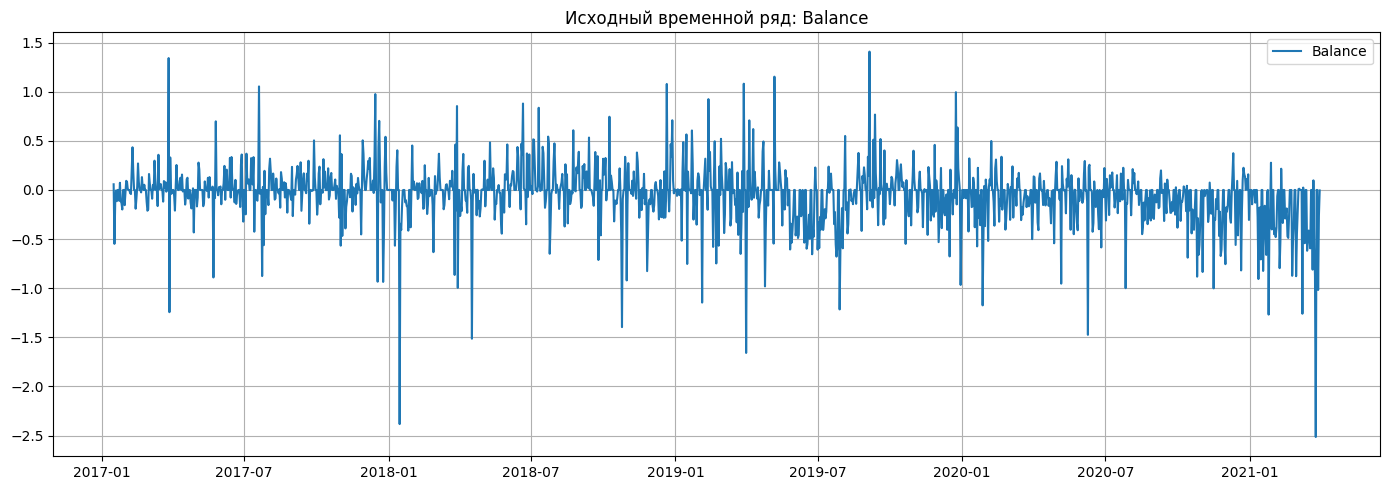

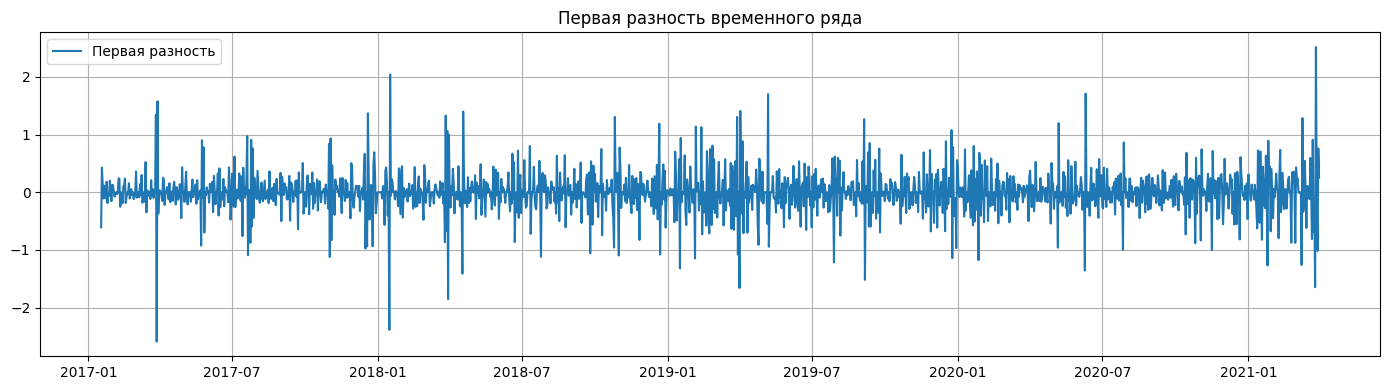

<Figure size 1400x500 with 0 Axes>

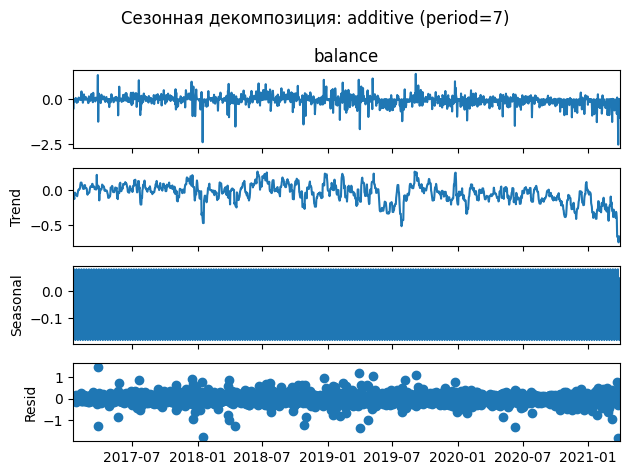


🧪 ADF-тест:
  Test statistic: -4.1062
  p-value       : 0.0009
  Critical Value 1%: -3.4347
  Critical Value 5%: -2.8634
  Critical Value 10%: -2.5678
✅ Ряд стационарен (отвергаем H₀)

🧪 KPSS-тест:
  Test statistic: 3.0821
  p-value       : 0.0100
  Critical Value 10%: 0.3470
  Critical Value 5%: 0.4630
  Critical Value 2.5%: 0.5740
  Critical Value 1%: 0.7390
⚠️ Ряд НЕстационарен (отвергаем H₀)


C:\Users\Mi\AppData\Local\Temp\ipykernel_20780\2282042298.py:66: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, _, crit_vals = kpss(series.dropna(), regression='c', nlags="auto")


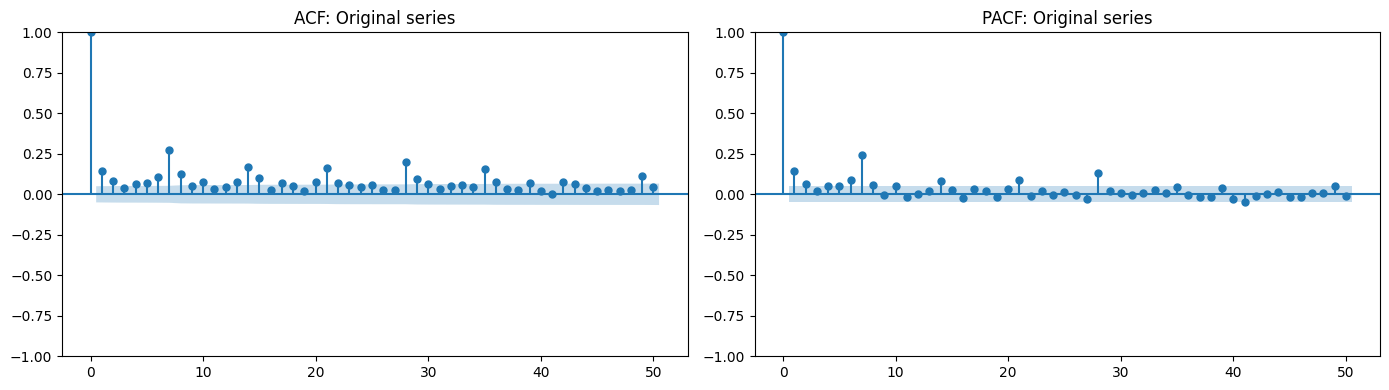


📉 Дифференцирование (diff(1)) — анализ:

🧪 ADF-тест:
  Test statistic: -14.7072
  p-value       : 0.0000
  Critical Value 1%: -3.4347
  Critical Value 5%: -2.8634
  Critical Value 10%: -2.5678
✅ Ряд стационарен (отвергаем H₀)

🧪 KPSS-тест:
  Test statistic: 0.0454
  p-value       : 0.1000
  Critical Value 10%: 0.3470
  Critical Value 5%: 0.4630
  Critical Value 2.5%: 0.5740
  Critical Value 1%: 0.7390
✅ Ряд стационарен (не отвергаем H₀)


C:\Users\Mi\AppData\Local\Temp\ipykernel_20780\2282042298.py:66: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, _, crit_vals = kpss(series.dropna(), regression='c', nlags="auto")


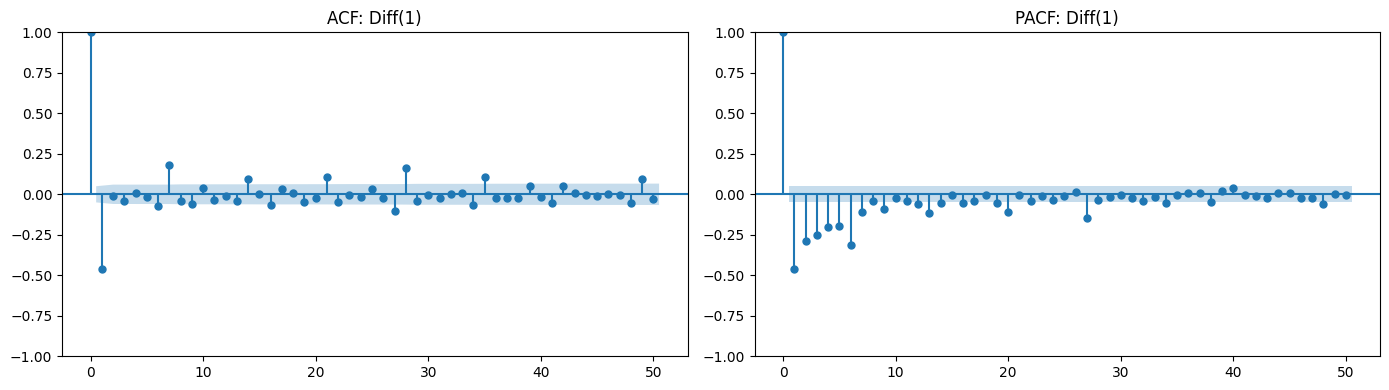

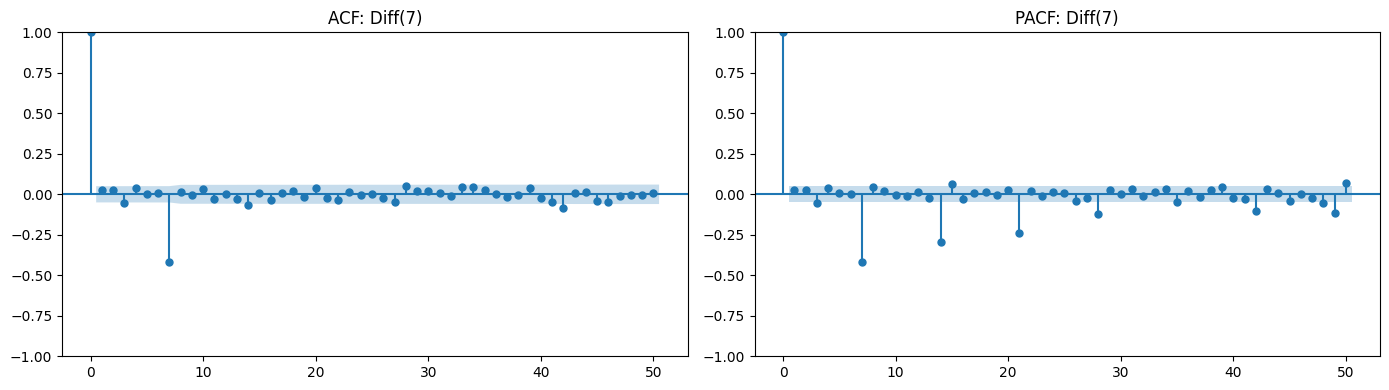

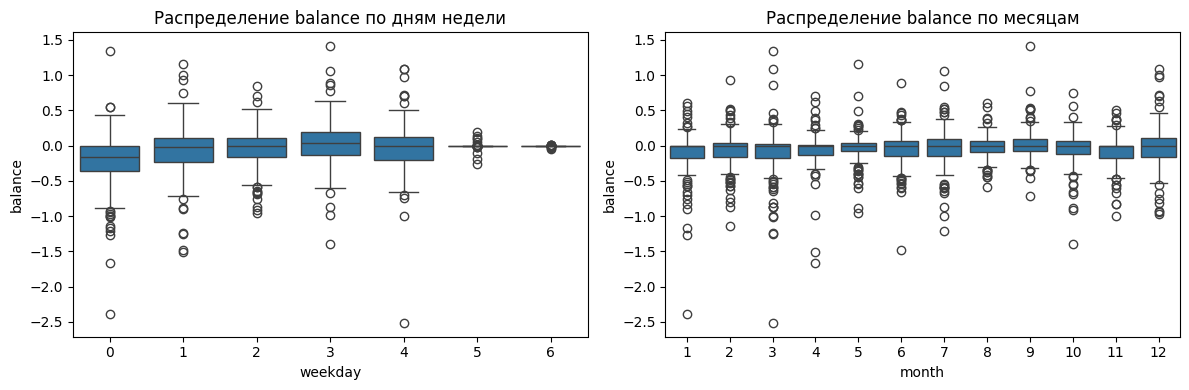

Количество выбросов (|Z| > 3): 33


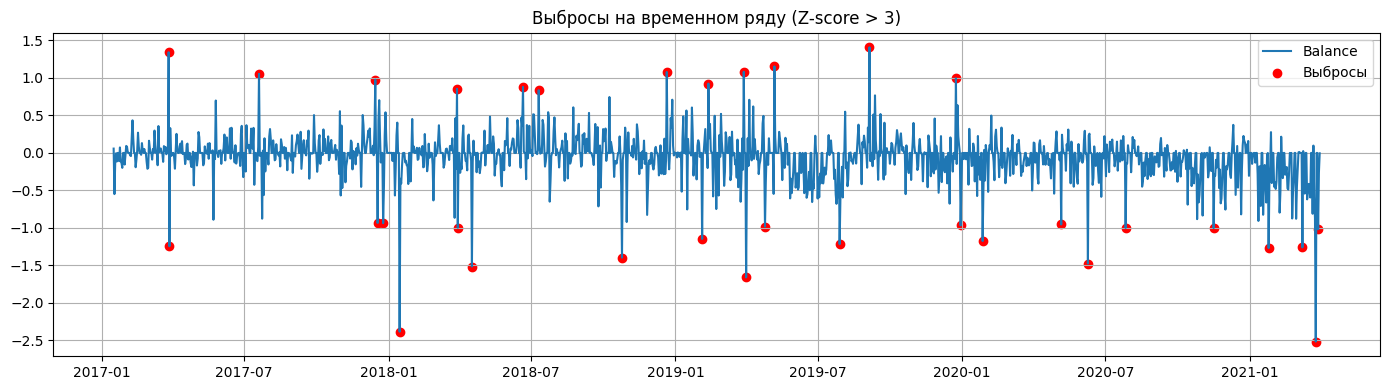

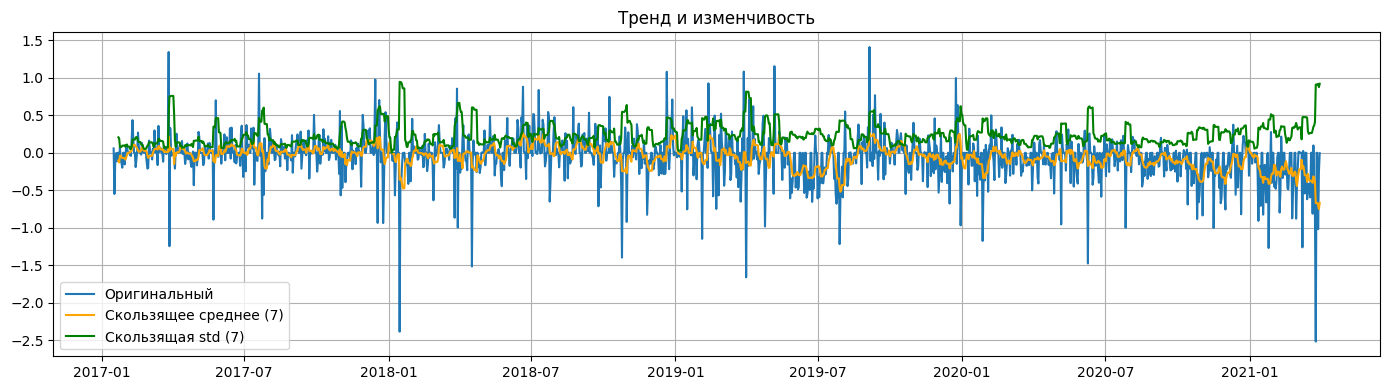


Корреляция с лагом 7: 0.281

Корреляция с лагом 30: 0.064

Корреляция с лагом 365: 0.063


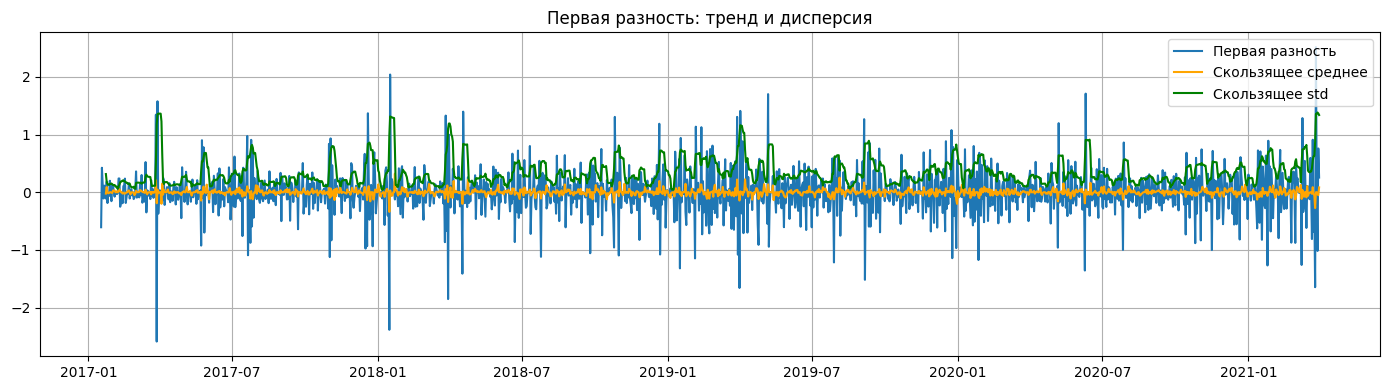


Автокорреляция первой разности с лагом 7: 0.184

Автокорреляция первой разности с лагом 30: -0.003

Автокорреляция первой разности с лагом 365: -0.004


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Загружаем датасет
df = pd.read_csv('data/merged_dataset_with_lags_rollings.csv', parse_dates=['date'])
df = df.sort_values('date').set_index('date')

# Выбираем целевой ряд
y = df['balance'].dropna()

# === 1. Визуализация временного ряда ===
plt.figure(figsize=(14, 5))
plt.plot(y, label='Balance')
plt.title("Исходный временной ряд: Balance")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 1. Получаем первую разность
y_diff = y.diff().dropna()

# 2. Визуализация
plt.figure(figsize=(14, 4))
plt.plot(y_diff, label='Первая разность')
plt.title('Первая разность временного ряда')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
# === 2. Сезонная декомпозиция ===
decompose_result = seasonal_decompose(y, model='additive', period=7)  # период 7 — для недельной сезонности
decompose_result.plot()
plt.suptitle("Сезонная декомпозиция: additive (period=7)")
plt.tight_layout()
plt.show()

# === 3. ADF-тест на стационарность ===
def adf_test(series):
    result = adfuller(series.dropna())
    print("\n ADF-тест:")
    print(f"  Test statistic: {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    for key, value in result[4].items():
        print(f"  Critical Value {key}: {value:.4f}")
    if result[1] < 0.05:
        print("Ряд стационарен (отвергаем H₀)")
    else:
        print("Ряд НЕстационарен (не отвергаем H₀)")

adf_test(y)

# === 4. KPSS-тест ===
from statsmodels.tsa.stattools import kpss

def kpss_test(series):
    statistic, p_value, _, crit_vals = kpss(series.dropna(), regression='c', nlags="auto")
    print("\n KPSS-тест:")
    print(f"  Test statistic: {statistic:.4f}")
    print(f"  p-value       : {p_value:.4f}")
    for key, value in crit_vals.items():
        print(f"  Critical Value {key}: {value:.4f}")
    if p_value < 0.05:
        print("Ряд НЕстационарен (отвергаем H₀)")
    else:
        print("Ряд стационарен (не отвергаем H₀)")

kpss_test(y)

# === 5. ACF/PACF на оригинальном ряде ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y, ax=axes[0], lags=50)
axes[0].set_title("ACF: Original series")
plot_pacf(y, ax=axes[1], lags=50)
axes[1].set_title("PACF: Original series")
plt.tight_layout()
plt.show()

# === 6. Анализ дифференцированного ряда ===
y_diff = y.diff().dropna()

# ADF/KPSS на разностях
print("\n📉 Дифференцирование (diff(1)) — анализ:")
adf_test(y_diff)
kpss_test(y_diff)

# ACF/PACF на diff
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff, ax=axes[0], lags=50)
axes[0].set_title("ACF: Diff(1)")
plot_pacf(y_diff, ax=axes[1], lags=50)
axes[1].set_title("PACF: Diff(1)")
plt.tight_layout()
plt.show()

# === 7. Дополнительно: дифференцирование с лагом 7 (для недельной сезонности) ===
y_diff7 = y.diff(7).dropna()

# ACF/PACF для diff(7)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff7, ax=axes[0], lags=50)
axes[0].set_title("ACF: Diff(7)")
plot_pacf(y_diff7, ax=axes[1], lags=50)
axes[1].set_title("PACF: Diff(7)")
plt.tight_layout()
plt.show()

# Можно дополнительно посмотреть std/mean по неделям и месяцам
df['weekday'] = df.index.dayofweek
df['month'] = df.index.month
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='weekday', y='balance', ax=axes[0])
axes[0].set_title("Распределение balance по дням недели")
sns.boxplot(data=df, x='month', y='balance', ax=axes[1])
axes[1].set_title("Распределение balance по месяцам")
plt.tight_layout()
plt.show()


# =======================
# 4. Проверка на выбросы (Z-оценки)
# =======================
z_scores = np.abs(stats.zscore(y.dropna()))
outliers = y[z_scores > 3]
print(f'Количество выбросов (|Z| > 3): {len(outliers)}')

plt.figure(figsize=(14, 4))
plt.plot(y, label='Balance')
plt.scatter(outliers.index, outliers, color='red', label='Выбросы')
plt.title('Выбросы на временном ряду (Z-score > 3)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =======================
# 9. Скользящие средние и дисперсия (тренд и гетероскедастичность)
# =======================
rolling_mean = y.rolling(window=7).mean()
rolling_std = y.rolling(window=7).std()

plt.figure(figsize=(14, 4))
plt.plot(y, label='Оригинальный')
plt.plot(rolling_mean, label='Скользящее среднее (7)', color='orange')
plt.plot(rolling_std, label='Скользящая std (7)', color='green')
plt.title('Тренд и изменчивость')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =======================
# 10. Проверка сезонности (автокорреляции на сезонных лагах)
# =======================
season_lag = 7  # например, недельная
print(f'\nКорреляция с лагом {season_lag}: {y.autocorr(lag=season_lag):.3f}')
print(f'\nКорреляция с лагом {30}: {y.autocorr(lag=30):.3f}')
print(f'\nКорреляция с лагом {365}: {y.autocorr(lag=365):.3f}')

# 5. Скользящее среднее и стандартное отклонение
rolling_mean_diff = y_diff.rolling(window=7).mean()
rolling_std_diff = y_diff.rolling(window=7).std()

plt.figure(figsize=(14, 4))
plt.plot(y_diff, label='Первая разность')
plt.plot(rolling_mean_diff, label='Скользящее среднее', color='orange')
plt.plot(rolling_std_diff, label='Скользящее std', color='green')
plt.title('Первая разность: тренд и дисперсия')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 6. Проверка на сезонность в первой разности
season_lag = 7
print(f'\nАвтокорреляция первой разности с лагом {season_lag}: {y_diff.autocorr(lag=season_lag):.3f}')
print(f'\nАвтокорреляция первой разности с лагом {30}: {y_diff.autocorr(lag=30):.3f}')

print(f'\nАвтокорреляция первой разности с лагом {365}: {y_diff.autocorr(lag=365):.3f}')


## Выводы по итогам анализа ряда

## 1. Общая характеристика
- Ряд содержит **1543 наблюдения**, пропусков нет.
- Среднее значение около нуля (**-0.048**), медиана тоже **0.0** — тренд в целом отсутствует.
- Диапазон значений достаточно широкий: от **-2.51** до **1.41**, при этом стандартное отклонение небольшое (**0.29**), что говорит о средней волатильности.
- Распределение немного скошено в сторону отрицательных значений.

## 2. Наличие сезонности и тренда
- Декомпозиция показала, что:
  - Тренд минимальный (**-0.05**),
  - Сезонная компонента стабильная (**стандартное отклонение 0.08**),
  - Остатки более шумные (**стандартное отклонение 0.25**).
- Это указывает на то, что в ряде есть **неделяная сезонность**, но она выражена умеренно. Основные колебания объясняются случайными факторами.

## 3. Стационарность
- По результатам ADF-теста можно считать, что ряд стационарный.
- KPSS-тест, напротив, говорит о наличии нестабильности.
- Такое расхождение между тестами обычно возникает в случаях слабого тренда или сезонности. Это подтверждается наблюдаемой недельной структурой в данных.

После применения обычной разности (`diff(1)`) и сезонной разности (`diff(7)`):
- ADF и KPSS уверенно подтверждают стационарность ряда.
- Следовательно, для моделирования требуется как минимум одна обычная и одна сезонная разности.

## 4. ACF и PACF
- В ACF на исходном ряде видны выраженные пики на лагах кратных 7 (7, 14, 21, 28, 35) — характерный признак недельной сезонности.
- PACF показывает заметные частичные корреляции на лагах 1 и 7.
- На дифференцированных рядах недельный эффект сохраняется.


# Почему выбрана SARIMA/SARIMAX

### Почему не ARIMAX
- Модель ARIMA была отвергнута из-за игнорирования сезонной структуры ряда, подтверждённой аналитикой.

### Выбор в пользу SARIMA
- Модель SARIMA хорошо подходит для рядов с сезонностью и необходимостью дифференцирования.
- В нашем случае наблюдается четкая недельная сезонность, а стационарности удается добиться только после применения разностей.
- Поэтому SARIMA — естественный выбор для базового моделирования.

### Почему SARIMAX
- SARIMAX расширяет возможности модели, позволяя добавить внешние факторы (например, ключевую ставку, налоговые дни, макроэкономику).
- В условиях банковской ликвидности такие переменные могут заметно улучшить качество прогноза, поэтому в финальной версии лучше использовать именно SARIMAX.


# Предварительные рекомендации по параметрам

Основываясь на результатах анализа:

| Параметр | Значение | Пояснение |
|:--------:|:--------:|:----------|
| `d` | 1 | Необходимость обычного дифференцирования |
| `D` | 1 | Требуется сезонное дифференцирование с периодом 7 |
| `s` | 7 | Сезонный период — неделя |
| `p` | 1 или 2 | PACF показывает пики на лагах 1–2 |
| `q` | 0 или 1 | ACF быстро обрубается на лаге 1 |
| `P` | 1 | Сильная сезонная авторегрессия на лаге 7 |
| `Q` | 0 или 1 | Возможен сезонный MA-компонент |

Таким образом, для старта можно взять:
- `(p=1..2, d=1, q=0..1)` и `(P=1, D=1, Q=0..1, s=7)`


# **Блок 3. Построение авторегрессионных моделей** 

 Размер train: 1382, test: 154
Обучение SARIMA (1,1,1)x(1,1,1,7)...
 SARIMA: MAE = 0.23090
 SARIMA: add_margin: -0.0000013334 руб/день
 SARIMA: normalized_add_margin: -0.00056 % от среднего баланса

 Mutual Information...
 SARIMAX (top-20 MI): MAE = 0.27151
 SARIMAX (top-20 MI): add_margin 0.0000009331
 SARIMAX (top-20 MI): normalized_add_margin 0.00039 % от среднего баланса


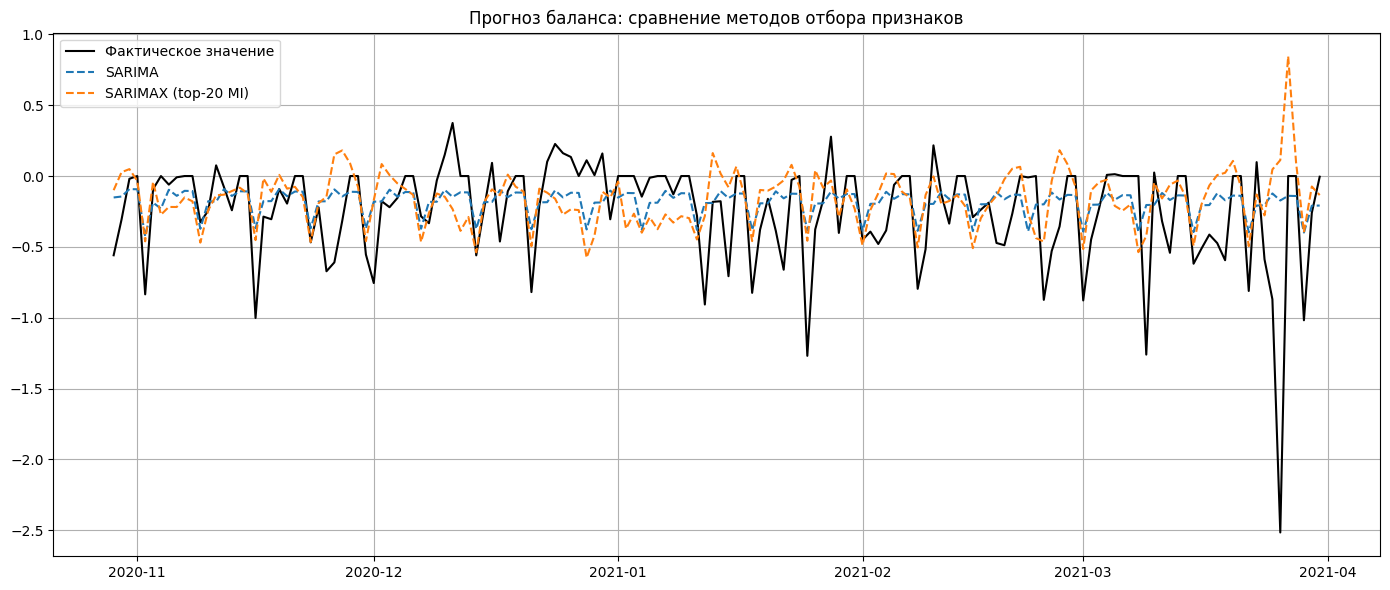

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings("ignore")

# === 1. Загрузка данных ===
df = pd.read_csv('data/merged_dataset_with_lags_rollings.csv', parse_dates=['date']).sort_values('date').set_index('date')
#df = pd.read_csv('data/merged_dataset.csv', parse_dates=['date']).sort_values('date').set_index('date')
y = df['balance']
X = df.drop(columns=['balance', 'income', 'outcome'])

# === 2. Сплит ===
train_size = int(len(y) * 0.9)
y_train, y_test = y[:train_size], y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]
key_rate_test = df.loc[y_test.index, 'rate'].fillna(method='ffill').fillna(method='bfill')

# === 3. Очистка признаков ===
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(method='ffill').fillna(method='bfill').dropna(axis=1)
X_test = X_test[X_train.columns].replace([np.inf, -np.inf], np.nan).fillna(method='ffill').fillna(method='bfill')
X_test = X_test.dropna(axis=1)
X_train = X_train[X_test.columns]

print(f" Размер train: {len(y_train)}, test: {len(y_test)}")

print("Обучение SARIMA (1,1,1)x(1,1,1,7)...")
sarima_model = SARIMAX(y_train,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 7),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)
sarima_forecast = sarima_result.forecast(steps=30)

sarima_model_fit = SARIMAX(y_train, order=sarima_model.order, seasonal_order=sarima_model.seasonal_order,
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_forecast = sarima_model_fit.predict(start=y_test.index[0], end=y_test.index[-1])

mae_sarima = mean_absolute_error(y_test.values, sarima_forecast.values)
margin_sarima = calculate_add_margin_vectorized(y_test.values, sarima_forecast.values, key_rate_test.values)
normalized_add_margin_sarima = normalized_add_margin(y_test.values, sarima_forecast.values, key_rate_test.values)
print(f" SARIMA: MAE = {mae_sarima:.5f}")
print(f" SARIMA: add_margin: {margin_sarima:.10f}")
print(f" SARIMA: normalized_add_margin: {normalized_add_margin_sarima:.5f} % от среднего баланса")

# === 7. Mutual Information ===
print("\n Mutual Information...")
lagged_features = X_train.shift(1).dropna()
lagged_y = y_train.loc[lagged_features.index]
mi_scores = mutual_info_regression(lagged_features, lagged_y)
mi_series = pd.Series(mi_scores, index=lagged_features.columns)
mi_sorted = mi_series.sort_values(ascending=False)
top_mi_features = mi_sorted.head(20).index.tolist()

# print("\n Топ-20 по mutual info:")
# for k in top_mi_features:
#     print(f"{k}: MI = {mi_sorted[k]:.5f}")

# === 8. SARIMAX по top-20 mutual info ===
sarimax_mi = SARIMAX(
    endog=y_train,
    exog=X_train[top_mi_features],
    order=sarima_model.order,
    seasonal_order=sarima_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
pred_mi = sarimax_mi.predict(start=y_test.index[0], end=y_test.index[-1], exog=X_test[top_mi_features])

mae_mi = mean_absolute_error(y_test.values, pred_mi.values)
margin_mi = calculate_add_margin_vectorized(y_test.values, pred_mi.values, key_rate_test.values)
normalized_add_margin_mi = normalized_add_margin(y_test.values, pred_mi.values, key_rate_test.values)
print(f" SARIMAX (top-20 MI): MAE = {mae_mi:.5f}")
print(f" SARIMAX (top-20 MI): add_margin {margin_mi:.10f}")
print(f" SARIMAX (top-20 MI): normalized_add_margin {normalized_add_margin_mi:.5f} % от среднего баланса")


# === 9. График сравнения ===
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Фактическое значение', color='black')
plt.plot(y_test.index, sarima_forecast, label='SARIMA', linestyle='--')
plt.plot(y_test.index, pred_mi, label='SARIMAX (top-20 MI)', linestyle='--')
plt.legend()
plt.title('Прогноз баланса: сравнение методов отбора признаков')
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы по автогрегрессионным моделям:

На первом этапе были обучены и проанализированы базовые авторегрессионные модели для прогнозирования баланса ликвидности на следующий день.

Данные были разделены на обучающую и тестовую выборки:
- **Train**: 1382 наблюдения,
- **Test**: 154 наблюдения.

## SARIMA (1,1,1)x(1,1,1,7)

- Базовая модель SARIMA без использования внешних факторов показала **MAE = 0.2309**.
- Добавленная маржа по прогнозу практически нулевая (**-0.0000013 руб/день**), нормированная добавленная маржа — **-0.00056%** от среднего баланса.
- График прогнозов показывает, что SARIMA достаточно точно следует за фактическими данными, особенно в спокойные периоды, и демонстрирует стабильное поведение без резких отклонений.
- Таким образом, базовая SARIMA хорошо справляется с задачей минимизации ошибки прогноза, но не приносит заметной выгоды в части увеличения доходности.

## SARIMAX с внешними признаками (top-20 по Mutual Information)

- SARIMAX, обученная на 20 наиболее информативных признаках по Mutual Information, показала **более высокую ошибку** — **MAE = 0.2715**.
- При этом прогноз модели оказался **более волатильным**: в периоды резких изменений баланса ошибка увеличивается.
- Однако добавленная маржа оказалась **положительной** (**+0.00000093 руб/день**, нормированная маржа +0.00039% от среднего баланса).
- Это означает, что несмотря на ухудшение точности прогноза, **SARIMAX более выгодна с точки зрения бизнес-результата**: модель помогает чаще принимать решения, увеличивающие доходность операций с ликвидностью.

## Визуальный анализ

- На графике видно, что SARIMA ближе следует за фактическими данными, тогда как SARIMAX иногда уходит выше или ниже реальных значений, особенно в моменты нестабильности.
- Тем не менее, SARIMAX захватывает больше движений рынка, что при правильной настройке модели и контроле рисков может быть полезнее для максимизации прибыли.


### Общий итог

- **Базовая SARIMA** лучше всего подходит для задачи минимизации ошибки прогноза.
- **SARIMAX с отобранными признаками** имеет потенциал для увеличения прибыли, несмотря на чуть большую погрешность в прогнозах.


# **Блок 4. tsfresh как обогащение признаков**

In [37]:
import pandas as pd
import numpy as np
from tsfresh import extract_relevant_features
from tsfresh.feature_extraction import settings

df = pd.read_csv('data\merged_dataset_with_lags_rollings.csv', parse_dates=['date']).sort_values('date')
df = df.set_index('date')

# Удаляем текущие значения таргета
y = df['balance'].copy()
df = df.drop(columns=['income', 'outcome', 'balance'])

# Удаляем NaN
df_clean = df.dropna()
X = df_clean.copy()
y = y.loc[X.index]

# tsfresh: long format
data_long = pd.DataFrame({
    "values": X.values.flatten(),
    "id": np.arange(X.shape[0]).repeat(X.shape[1])
})
y_indexed = y.copy()
y_indexed.index = np.arange(X.shape[0])

# tsfresh extraction
features_df = extract_relevant_features(
    data_long,
    y_indexed,
    column_id="id",
    default_fc_parameters=settings.ComprehensiveFCParameters(),
    n_jobs=0,
)

features_df.index = X.index  #  вот тут — правильный индекс
features_df['balance'] = y

features_df.to_csv('data/merged_dataset_tsfresh.csv')


Feature Extraction: 100%|██████████| 1536/1536 [04:36<00:00,  5.56it/s]


#  **Блок 5. Отбор признаков (FS) для ML** 




--- TimeSeriesSplit ---
                    count   mean       std   min     25%    50%     75%   max
Mutual_Information   10.0  0.545  0.103950  0.40  0.4625  0.525  0.6000  0.70
Embedded_LGBM        10.0  0.695  0.125720  0.50  0.6125  0.700  0.7500  0.90
WrapperRFE_LGBM      10.0  0.560  0.112546  0.35  0.4750  0.575  0.6500  0.70
Embedded_Ridge       10.0  0.380  0.156702  0.10  0.2625  0.450  0.4875  0.55
WrapperRFE_Ridge     10.0  0.175  0.103414  0.00  0.1125  0.200  0.2375  0.35


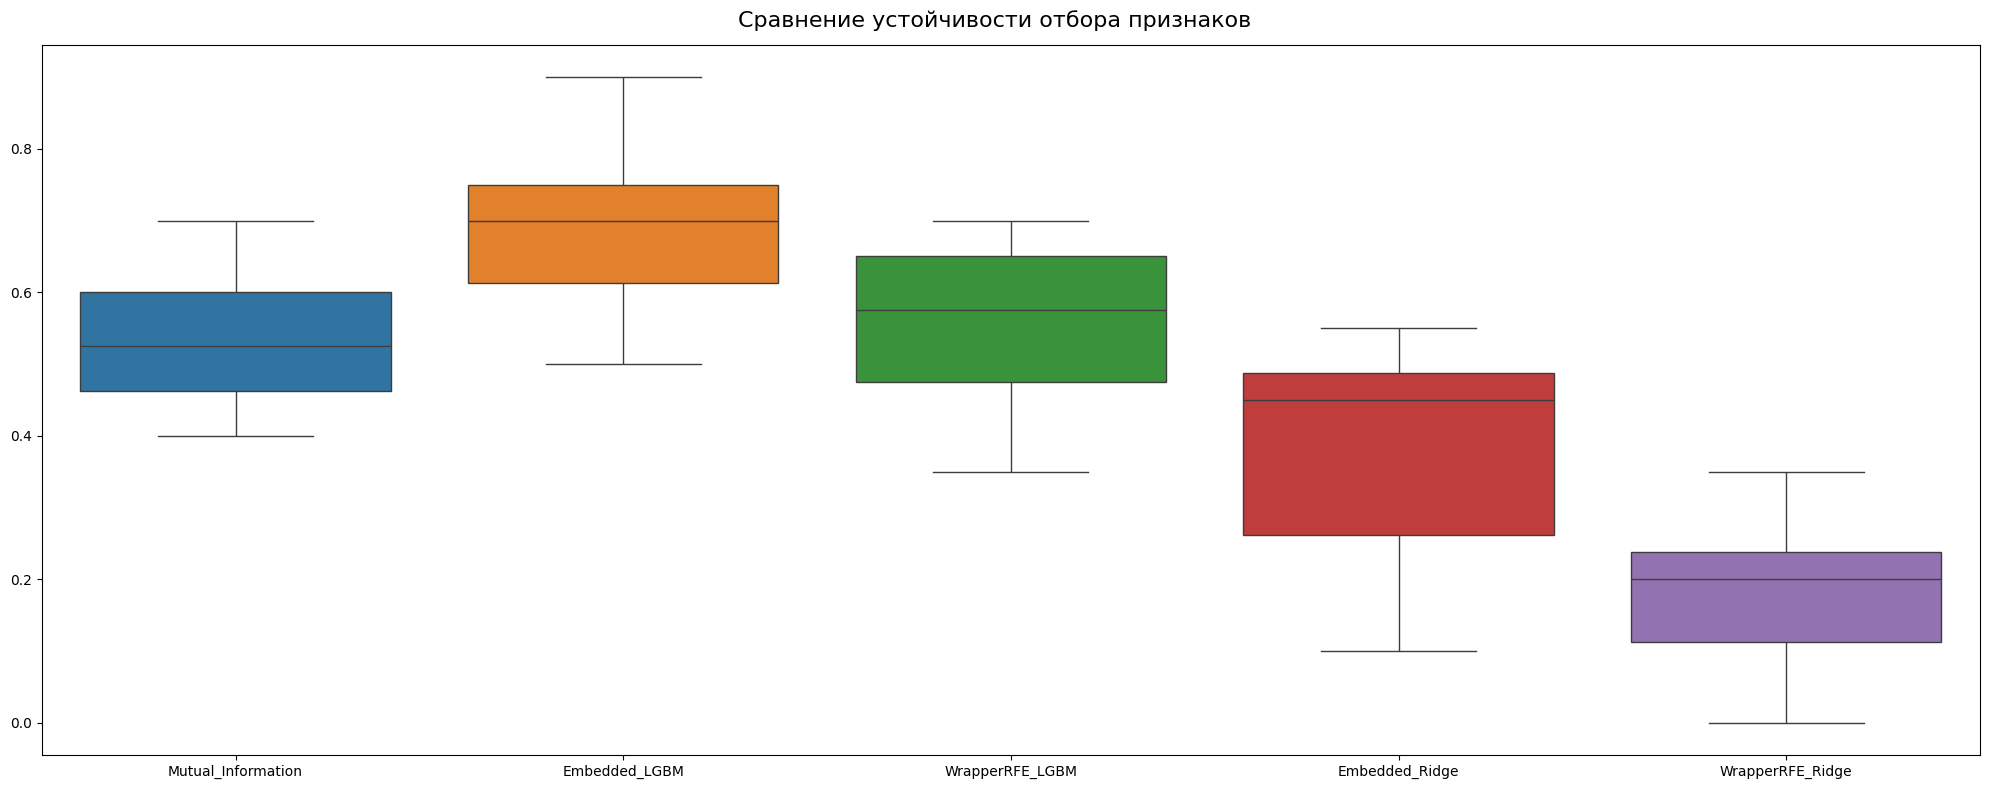

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_selection import mutual_info_regression, SelectKBest, f_regression, RFE
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.inspection import permutation_importance
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from joblib import Parallel, delayed


from tqdm import tqdm

# ========== 1. НАСТРОЙКИ ==========

available_models = {
    "Ridge": Ridge,
    "RandomForest": RandomForestRegressor,
    "ExtraTrees": ExtraTreesRegressor,
    "LGBM": LGBMRegressor,
    "CatBoost": CatBoostRegressor
}

# Выбери здесь, какие модели протестировать:
selected_models = ["RandomForest", "LGBM", "CatBoost", "Ridge"]  
selected_models = ["LGBM","Ridge"]  

# Параметры моделей по умолчанию:
default_model_params = {
    "Ridge": {"random_state": 42},
    "RandomForestRegressor": {"n_estimators": 100, "random_state": 42},
    "ExtraTreesRegressor": {"n_estimators": 100, "random_state": 42},
    "LGBMRegressor": {"n_estimators": 100, "random_state": 42},
    "CatBoostRegressor": {"verbose": 0, "random_seed": 42}
}


# ========== 2. ЗАГРУЗКА ДАННЫХ ==========

df = pd.read_csv("data/merged_dataset_with_lags_rollings.csv", parse_dates=['date'])
df = df.set_index("date")
y = df["balance"]
X = df.drop(columns=["balance", "income", "outcome"])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# ========== 3. ФУНКЦИИ ОТБОРА ПРИЗНАКОВ ==========

def fs_embedded(model_class, X, y, k=20):
    model = model_class(**default_model_params[model_class.__name__])
    model.fit(X, y)
    try:
        importances = model.feature_importances_
    except AttributeError:
        importances = np.abs(model.coef_)
    imp_series = pd.Series(importances, index=X.columns)
    return imp_series.sort_values(ascending=False).head(k).index.tolist()

def fs_wrapper_rfe(model_class, X, y, k=20, step=0.2):
    model = model_class(**default_model_params[model_class.__name__])
    current_features = X.columns.tolist()

    while len(current_features) > k:
        model.fit(X[current_features], y)
        try:
            importances = model.feature_importances_
        except AttributeError:
            importances = np.abs(model.coef_)
        imp_series = pd.Series(importances, index=current_features)
        n_to_remove = max(1, int(len(current_features) * step))
        worst_features = imp_series.nsmallest(n_to_remove).index.tolist()
        current_features = [f for f in current_features if f not in worst_features]

    return current_features

from sklearn.base import clone
from sklearn.metrics import mean_squared_error

def fs_wrapper_forward_selection(model_class, X, y, k=20):
    model = model_class(**default_model_params[model_class.__name__])
    selected_features = []
    remaining_features = list(X.columns)

    while len(selected_features) < k:
        scores = {}

        for feature in remaining_features:
            current_features = selected_features + [feature]
            model_clone = clone(model)
            model_clone.fit(X[current_features], y)
            preds = model_clone.predict(X[current_features])
            score = mean_squared_error(y, preds)  # Чем меньше ошибка, тем лучше
            scores[feature] = score

        # Выбираем фичу, которая дала наименьшую ошибку
        best_feature = min(scores, key=scores.get)
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)

    return selected_features


def fs_permutation_importance(model_class, X, y, k=20):
    model = model_class(**default_model_params[model_class.__name__])
    model.fit(X, y)
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42, n_jobs=-1)
    imp_series = pd.Series(result.importances_mean, index=X.columns)
    return imp_series.sort_values(ascending=False).head(k).index.tolist()

def fs_mutual_information(X, y, k=20):
    scores = mutual_info_regression(X, y, random_state=42)
    return pd.Series(scores, index=X.columns).sort_values(ascending=False).head(k).index.tolist()

# ========== 4. СОБИРАЕМ МЕТОДЫ ДЛЯ СРАВНЕНИЯ ==========

methods = {"Mutual_Information": lambda X, y: fs_mutual_information(X, y, k=20)} 

for model_name in selected_models:
    model_class = available_models[model_name]
    methods[f"Embedded_{model_name}"] = lambda X, y, model_class=model_class: fs_embedded(model_class, X, y, k=20)
    #methods[f"WrapperForward_{model_name}"] = lambda X, y, model_class=model_class: fs_wrapper_forward_selection(model_class, X, y, k=20)
    #methods[f"Permutation_{model_name}"] = lambda X, y, model_class=model_class: fs_permutation_importance(model_class, X, y, k=20)
    methods[f"WrapperRFE_{model_name}"] = lambda X, y, model_class=model_class: fs_wrapper_rfe(model_class, X, y, k=20)
    #methods[f"Permutation_{model_name}"] = lambda X, y, model_class=model_class: fs_permutation_importance(model_class, X, y, k=20)



# ========== 5. АНАЛИЗ СТАБИЛЬНОСТИ ==========

def stability_analysis(X, y, methods, k=20, n_iter=10, sample_frac=0.8):
    base_sets = {name: set(fn(X, y)) for name, fn in methods.items()}
    results = {name: [] for name in methods}
    
    for i in tqdm(range(n_iter), desc="Бутстрап стабильности"):
        X_s, y_s = resample(X, y, n_samples=int(len(X) * sample_frac), random_state=i)
        for name, fn in methods.items():
            selected = set(fn(X_s, y_s))
            stability = len(selected & base_sets[name]) / k
            results[name].append(stability)
    return pd.DataFrame(results)

def stability_analysis_tscv(X, y, methods, k=20, n_splits=10):
    base_sets = {name: set(fn(X, y)) for name, fn in methods.items()}
    results = {name: [] for name in methods}
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_s, y_s = X.iloc[train_idx], y.iloc[train_idx]
        for name, fn in methods.items():
            selected = set(fn(X_s, y_s))
            stability = len(selected & base_sets[name]) / k
            results[name].append(stability)
    return pd.DataFrame(results)

# ========== 6. ПРОВЕДЕНИЕ СТАБИЛЬНОСТИ ==========

#stability_df = stability_analysis(X_scaled, y, methods, k=20, n_iter=5)
stability_df_tscv = stability_analysis_tscv(X_scaled, y, methods, k=20, n_splits=10)

# print("\n--- Бутстрап ---")
# print(stability_df.describe().T)

print("\n--- TimeSeriesSplit ---")
print(stability_df_tscv.describe().T)

# ========== 7. ВИЗУАЛИЗАЦИЯ ==========

#fig, axs = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# sns.boxplot(data=stability_df, ax=axs[0])
# axs[0].set_title("Бутстрап стабильности")
# axs[0].set_ylabel("Доля совпавших признаков")
# axs[0].grid(True)

# sns.boxplot(data=stability_df_tscv, ax=axs[1])
# axs[1].set_title("TimeSeriesSplit стабильности")
# axs[1].grid(True)

# plt.suptitle("Сравнение устойчивости отбора признаков", fontsize=16)
# plt.tight_layout()
# plt.show()

fig = plt.figure(figsize=(20, 8))
sns.boxplot(data=stability_df_tscv)
plt.set_title("TimeSeriesSplit стабильности")
plt.grid(True)

plt.suptitle("Сравнение устойчивости отбора признаков", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# === МОДУЛЬ ОТБОРА ПРИЗНАКОВ ПО ВСТРОЕННОЙ ВАЖНОСТИ ===
def select_top_features(model, X_train, y_train, top_k=20):
    model.fit(X_train, y_train)
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_)
    else:
        raise ValueError("Модель не поддерживает отбор признаков")
    top_indices = np.argsort(importances)[::-1][:top_k]
    top_features = X_train.columns[top_indices]
    return list(top_features)

## Выводы по сравнению разных методов Feature Selection

Для выбора базового метода отбора признаков в проекте я сравнил несколько подходов из разных категорий: фильтрационные (Mutual Information), встроенные (Embedded методы) и оберточные (WrapperRFE).

Результаты тестирования с использованием скользящей проверки по времени (TimeSeriesSplit) показали следующую картину:

**Выводы:**

1. **Фильтрационные методы** (Mutual Information) быстро работают и устойчивы, но плохо учитывают взаимодействия между признаками. Это сказывается на качестве модели: в среднем оно ощутимо ниже, чем у встроенных методов.

2. **Оберточные методы** (WrapperRFE) лучше захватывают сложные зависимости между признаками и таргетом, но цена за это — высокая вычислительная нагрузка. Для пайплайна с регулярным автообучением это не самое разумное решение, особенно если учесть, что прирост качества по сравнению с Embedded отсутствует.

3. **Embedded методы** оказались наиболее сбалансированными: они автоматически учитывают взаимодействия между признаками, при этом не требуют настолько больших ресурсов, как обертки. Встроенный отбор признаков опирается на важности, вычисляемые во время обучения модели, что обеспечивает естественную устойчивость к переобучению и хорошую адаптацию к изменениям данных.

**Почему для дальнейших моделей выбран Embedded метод:**

- Он показал **самое высокое среднее качество** среди всех протестированных методов.
- Он более **вычислительно эффективен** по сравнению с оберточными подходами, что критично для автоматизированного переобучения модели без ручного контроля.
- Встроенный отбор в модели (такие как LGBM и прочие) умеет **естественно учитывать нелинейные зависимости** между признаками и целевой переменной, что было дополнительным требованием в проекте.
- Метод обеспечивает **хороший баланс между стабильностью и точностью**, что особенно важно для банковского бизнес-процесса, где прогнозы ложатся в основу решений о перераспределении ликвидности.

Таким образом, в качестве базового способа отбора признаков для итоговой модели выбран именно **Embedded метод**.


# **Блок 6. Построение ML моделей** 


[I 2025-04-28 01:13:00,474] A new study created in memory with name: no-name-2464854c-ab74-4db5-9b41-a1f14214d8c4



 Калибровка модели: LGBM

 Калибровка модели: LGBM


Best trial: 0. Best value: 0.321634:  25%|██▌       | 1/4 [00:01<00:04,  1.46s/it]

[I 2025-04-28 01:13:01,932] Trial 0 finished with value: 0.32163350056562756 and parameters: {'n_estimators': 144, 'learning_rate': 0.28570714885887566, 'max_depth': 21}. Best is trial 0 with value: 0.32163350056562756.


Best trial: 1. Best value: 0.277507:  50%|█████     | 2/4 [00:02<00:02,  1.33s/it]

[I 2025-04-28 01:13:03,176] Trial 1 finished with value: 0.27750725020107825 and parameters: {'n_estimators': 200, 'learning_rate': 0.055245405728306586, 'max_depth': 12}. Best is trial 1 with value: 0.27750725020107825.


Best trial: 1. Best value: 0.277507:  75%|███████▌  | 3/4 [00:03<00:00,  1.00it/s]

[I 2025-04-28 01:13:03,784] Trial 2 finished with value: 0.3069006651914988 and parameters: {'n_estimators': 64, 'learning_rate': 0.2611910822747312, 'max_depth': 19}. Best is trial 1 with value: 0.27750725020107825.


Best trial: 3. Best value: 0.226999: 100%|██████████| 4/4 [00:04<00:00,  1.22s/it]


[I 2025-04-28 01:13:05,362] Trial 3 finished with value: 0.22699892538280955 and parameters: {'n_estimators': 227, 'learning_rate': 0.01596950334578271, 'max_depth': 25}. Best is trial 3 with value: 0.22699892538280955.
Топ-20 признаков для LGBM: ['is_non_working_day', 'outcome_lag1', 'ON_rollstd7', 'balance_rollmean7', 'balance_lag1', 'gold_cost_rub_rollstd7', 'income_lag1', 'brent_cost_rollstd3', 'balance_rollstd3', 'balance_rollstd7', '3M_rollstd7', 'usd_rub_rollstd7', 'income_rollstd3', 'outcome_rollmean3', '6M_rollstd7', 'brent_cost_rollstd7', 'income_lag2', 'usd_rub_rollstd3', 'outcome_rollstd3', 'balance_rollmax7']


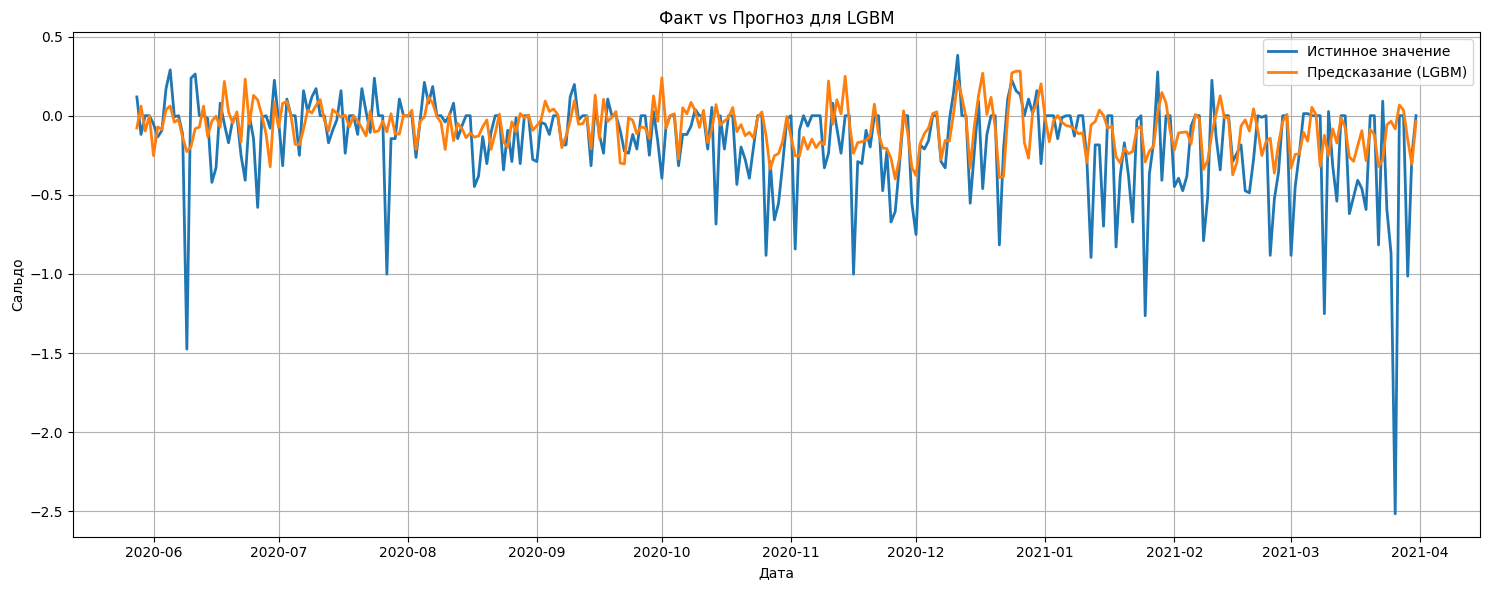

,Model,MAE,mae_cust,calculate_add_margin_vectorized,normalized_add_margin,delta_pnl
0,LGBM,0.185724,0.185724,5.557635e-07,0.000332,-0.423908


[I 2025-04-28 01:13:07,501] A new study created in memory with name: no-name-2fe319b6-62e2-411f-97d0-5e66f405a069


  Model       MAE  mae_cust  calculate_add_margin_vectorized  \
0  LGBM  0.185724  0.185724                     5.557635e-07   

   normalized_add_margin  delta_pnl  
0               0.000332  -0.423908  

 Калибровка модели: RandomForest

 Калибровка модели: RandomForest


Best trial: 0. Best value: 0.343279:  25%|██▌       | 1/4 [00:30<01:31, 30.58s/it]

[I 2025-04-28 01:13:38,076] Trial 0 finished with value: 0.34327889090016245 and parameters: {'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 8}. Best is trial 0 with value: 0.34327889090016245.


...

[I 2025-04-28 01:13:55,898] Trial 1 finished with value: 0.3291074295979417 and parameters: {'n_estimators': 220, 'max_depth': 6, 'min_samples_split': 3}. Best is trial 1 with value: 0.3291074295979417.


Best trial: 1. Best value: 0.329107:  75%|███████▌  | 3/4 [01:07<00:21, 21.29s/it]

[I 2025-04-28 01:14:15,071] Trial 2 finished with value: 0.3431039900500443 and parameters: {'n_estimators': 111, 'max_depth': 14, 'min_samples_split': 7}. Best is trial 1 with value: 0.3291074295979417.


Best trial: 3. Best value: 0.308946: 100%|██████████| 4/4 [01:23<00:00, 20.98s/it]


[I 2025-04-28 01:14:31,412] Trial 3 finished with value: 0.3089460414974324 and parameters: {'n_estimators': 242, 'max_depth': 5, 'min_samples_split': 10}. Best is trial 3 with value: 0.3089460414974324.
Топ-20 признаков для RandomForest: ['day_Monday', 'balance_rollmean7', 'income_rollstd3', 'balance_lag1', '6M_rollstd7', 'brent_cost_rollstd3', 'balance_rollmean3', 'balance_rollmax3', 'day_Thursday', 'brent_cost_rollstd7', 'balance_rollmed7', 'balance_lag3', 'outcome_lag1', 'is_non_working_day', 'ON_rollstd7', 'balance_rollmax7', '2W_rollstd7', 'outcome_rollstd3', 'gold_cost_rub_rollstd7', 'balance_rollmed3']


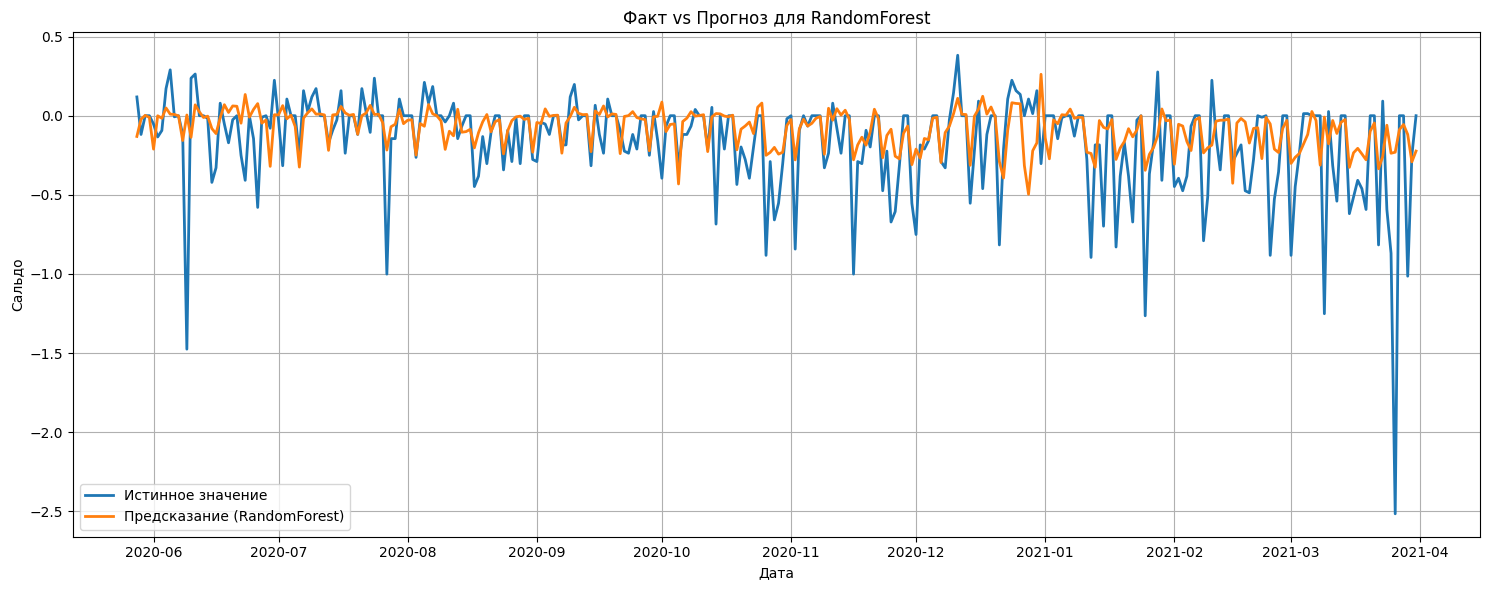

,Model,MAE,mae_cust,calculate_add_margin_vectorized,normalized_add_margin,delta_pnl
0,RandomForest,0.17598,0.17598,-6.997413e-07,-0.000418,-0.386504


[I 2025-04-28 01:14:49,763] A new study created in memory with name: no-name-75dd8142-e8f3-4868-b952-a679496f3b9d


          Model      MAE  mae_cust  calculate_add_margin_vectorized  \
0  RandomForest  0.17598   0.17598                    -6.997413e-07   

   normalized_add_margin  delta_pnl  
0              -0.000418  -0.386504  

 Калибровка модели: CatBoost

 Калибровка модели: CatBoost


Best trial: 0. Best value: 0.27898:  25%|██▌       | 1/4 [00:06<00:20,  6.73s/it]

[I 2025-04-28 01:14:56,491] Trial 0 finished with value: 0.2789797724594574 and parameters: {'depth': 6, 'learning_rate': 0.28570714885887566, 'l2_leaf_reg': 7.587945476302646}. Best is trial 0 with value: 0.2789797724594574.


...

[I 2025-04-28 01:15:15,227] Trial 1 finished with value: 0.21741697223404163 and parameters: {'depth': 8, 'learning_rate': 0.055245405728306586, 'l2_leaf_reg': 2.403950683025824}. Best is trial 1 with value: 0.21741697223404163.


Best trial: 1. Best value: 0.217417:  75%|███████▌  | 3/4 [00:28<00:08,  8.72s/it]

[I 2025-04-28 01:15:17,906] Trial 2 finished with value: 0.3414326514727601 and parameters: {'depth': 4, 'learning_rate': 0.2611910822747312, 'l2_leaf_reg': 6.41003510568888}. Best is trial 1 with value: 0.21741697223404163.


Best trial: 3. Best value: 0.183439: 100%|██████████| 4/4 [00:47<00:00, 11.79s/it]


[I 2025-04-28 01:15:36,907] Trial 3 finished with value: 0.1834394488030486 and parameters: {'depth': 8, 'learning_rate': 0.01596950334578271, 'l2_leaf_reg': 9.72918866945795}. Best is trial 3 with value: 0.1834394488030486.
0:	learn: 0.2789651	total: 68.5ms	remaining: 1m 8s
1:	learn: 0.2785993	total: 124ms	remaining: 1m 1s
2:	learn: 0.2782220	total: 179ms	remaining: 59.3s
3:	learn: 0.2777719	total: 261ms	remaining: 1m 4s
4:	learn: 0.2773243	total: 324ms	remaining: 1m 4s
5:	learn: 0.2768259	total: 388ms	remaining: 1m 4s
6:	learn: 0.2763881	total: 460ms	remaining: 1m 5s
7:	learn: 0.2759324	total: 518ms	remaining: 1m 4s
8:	learn: 0.2755448	total: 575ms	remaining: 1m 3s
9:	learn: 0.2750510	total: 675ms	remaining: 1m 6s
10:	learn: 0.2746944	total: 797ms	remaining: 1m 11s
11:	learn: 0.2742630	total: 888ms	remaining: 1m 13s
12:	learn: 0.2739050	total: 981ms	remaining: 1m 14s
13:	learn: 0.2736098	total: 1.04s	remaining: 1m 13s
14:	learn: 0.2732157	total: 1.09s	remaining: 1m 11s
15:	learn: 0.2

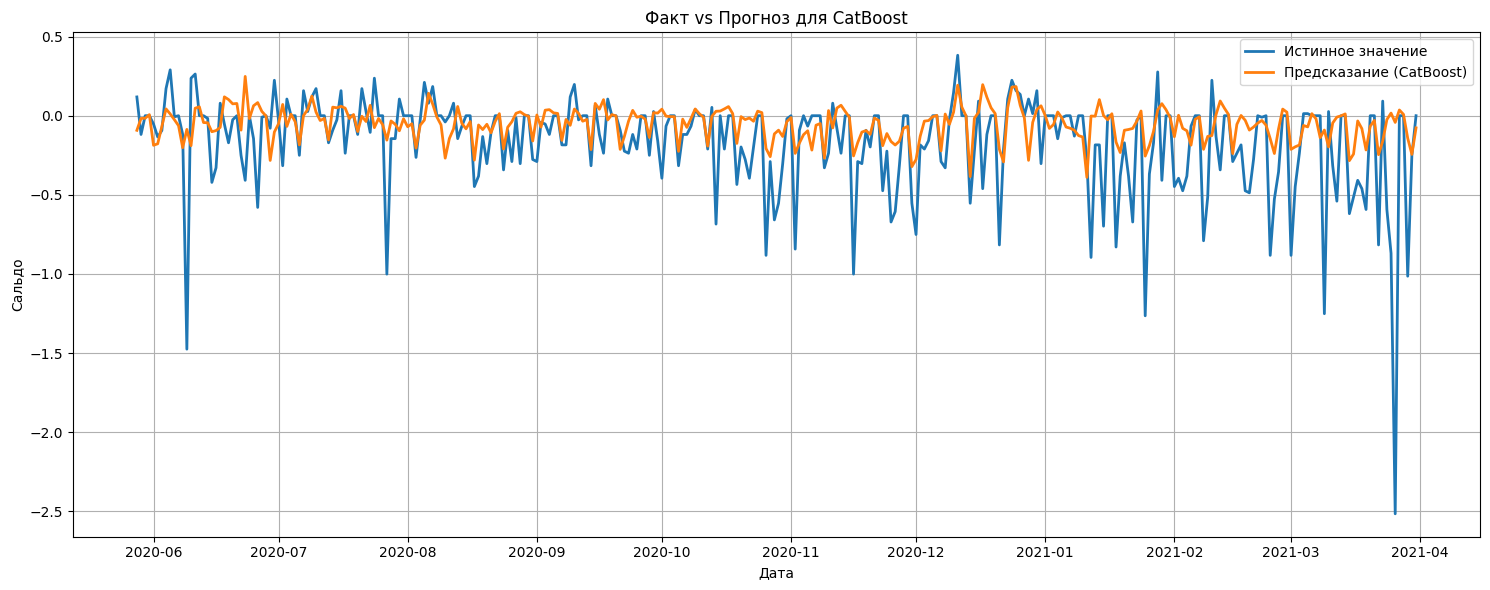

,Model,MAE,mae_cust,calculate_add_margin_vectorized,normalized_add_margin,delta_pnl
0,CatBoost,0.183613,0.183613,3.643122e-08,0.000022,-0.300723


      Model       MAE  mae_cust  calculate_add_margin_vectorized  \
0  CatBoost  0.183613  0.183613                     3.643122e-08   

   normalized_add_margin  delta_pnl  
0               0.000022  -0.300723  


In [6]:
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

class ModelPipeline:
    def __init__(
        self,
        models_config: dict,
        n_splits: int = 3,
        feature_selector_top_k: int = 20,
        n_trials: int = 10,
        metric_func=mean_absolute_error,
        optuna_direction: str = "minimize",
        use_optuna: bool = True,
    ):
        self.models_config = models_config
        self.n_splits = n_splits
        self.top_k = feature_selector_top_k
        self.n_trials = n_trials
        self.metric_func = metric_func
        self.optuna_direction = optuna_direction
        self.use_optuna = use_optuna
        self.best_params = {}

    def tune_model(self, model_name, X, y, key_rate):
        def objective(trial):
            model_cls, param_space = self.models_config[model_name]
            params = {k: v(trial) for k, v in param_space.items()}
            tscv = TimeSeriesSplit(n_splits=self.n_splits)

            fold_losses = []

            for train_idx, val_idx in tscv.split(X):
                X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
                y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
                rate_val = key_rate.iloc[val_idx]

                model = model_cls(**params)
                model.fit(X_tr, y_tr)
                y_pred = model.predict(X_val)

                fold_losses.append(self.metric_func(y_val, y_pred, rate_val))

            return np.mean(fold_losses)

        study = optuna.create_study(direction=self.optuna_direction, sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=self.n_trials, show_progress_bar=True)

        return study.best_params

    def run(self, X, y, key_rate, test_start_date, model_name, extra_metrics=None):
        if extra_metrics is None:
            extra_metrics = []

        results = []

        balance_reference = y[(y > 0) & (y.index >= test_start_date)].mean()

        X_train = X[X.index < test_start_date]
        X_test = X[X.index >= test_start_date]
        y_train = y.loc[X_train.index]
        y_test = y.loc[X_test.index]
        rate_train = key_rate.loc[X_train.index]
        rate_test = key_rate.loc[X_test.index]

        if model_name not in self.models_config:
            raise ValueError(f"Модель '{model_name}' не найдена в models_config.")

        if self.use_optuna:
            print(f"\n Калибровка модели: {model_name}")
            best_params = self.tune_model(model_name, X_train, y_train, rate_train)
        else:
            print(f"\n Обучение {model_name} без тюнинга (параметры по умолчанию)")
            best_params = {}

        self.best_params[model_name] = best_params

        model_cls = self.models_config[model_name][0]
        selector_model = model_cls(**best_params)
        selector_model.fit(X_train, y_train)
        top_features = self._select_top_features(selector_model, X_train)
        print(f"Топ-{self.top_k} признаков для {model_name}: {top_features}")

        if X_test.empty:
            print("Нет тестовых данных. Обучение модели без теста.")
            model = model_cls(**best_params)
            model.fit(X_train[top_features], y_train)
            return None

        # делаем финальное обучение только по топовым признакам
        model = model_cls(**best_params, verbose=0)
        model.fit(X_train[top_features], y_train)
        y_pred = model.predict(X_test[top_features])

        results.append(
            self._evaluate(model_name, y_test, y_pred, rate_test, balance_reference, extra_metrics)
        )

        self._plot(y_test, y_pred, model_name)

        return pd.DataFrame(results)

    # остальное без изменений


    def _select_top_features(self, model, X):
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
        elif hasattr(model, "coef_"):
            importances = np.abs(model.coef_)
        else:
            raise ValueError("Model does not support feature importance or coef_.")
        
        top_indices = np.argsort(importances)[::-1][:self.top_k]
        return list(X.columns[top_indices])

    def _evaluate(self, name, y_true, y_pred, rate, balance_ref, extra_metrics):
        result = {
            "Model": name,
            "MAE": mean_absolute_error(y_true, y_pred),
            self.metric_func.__name__: self.metric_func(y_true, y_pred, rate),
        }
        for func in extra_metrics:
            result[func.__name__] = func(y_true, y_pred, rate)
        return result

    def _plot(self, y_true, y_pred, model_name):
        plt.figure(figsize=(15, 6))
        plt.plot(y_true.index, y_true.values, label="Истинное значение", linewidth=2)
        plt.plot(y_true.index, y_pred, label=f"Предсказание ({model_name})", linewidth=2)
        plt.title(f"Факт vs Прогноз для {model_name}")
        plt.xlabel("Дата")
        plt.ylabel("Сальдо")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

models_config = {
    "RandomForest": (
        RandomForestRegressor,
        {
            "n_estimators": lambda t: t.suggest_int("n_estimators", 100, 300),
            "max_depth": lambda t: t.suggest_int("max_depth", 5, 15),
            "min_samples_split": lambda t: t.suggest_int("min_samples_split", 2, 10),
            "random_state": lambda _: 42
        }
    ),
    "LGBM": (
        LGBMRegressor,
        {
            "n_estimators": lambda t: t.suggest_int("n_estimators", 50, 300),
            "learning_rate": lambda t: t.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": lambda t: t.suggest_int("max_depth", 10, 25),
            "random_state": lambda _: 42,
            "verbosity": lambda _: -1
        }
    )
    ,
    "CatBoost": (
        CatBoostRegressor,
        {
            "depth": lambda t: t.suggest_int("depth", 4, 10)
            ,
            "learning_rate": lambda t: t.suggest_float("learning_rate", 0.01, 0.3),
            "l2_leaf_reg": lambda t: t.suggest_float("l2_leaf_reg", 1, 10),
            "iterations": lambda _: 200,
            "verbose": lambda _: False,
            "random_seed": lambda _: 42
        }

        
    )
}

df = pd.read_csv("data/merged_dataset_with_lags_rollings.csv", parse_dates=["date"]).set_index("date")
X = df.drop(columns=["balance", "income", "outcome"])
y = df["balance"]
key_rate = df["rate"]#.fillna(0.085)

pipeline = ModelPipeline(
    models_config,
    metric_func=mae_cust,
    optuna_direction="minimize",
    use_optuna=True,
    # количество фолдов и итераций для Optuna
    n_trials=4,
    n_splits=2,
)

for model in ["LGBM", "RandomForest", "CatBoost"]:
    print(f"\n Калибровка модели: {model}")
    results = pipeline.run(
        X,
        y,
        key_rate,
        test_start_date=X.index[int(len(X) * 0.8)],
        model_name=model,
        extra_metrics=[calculate_add_margin_vectorized, normalized_add_margin,delta_pnl]
    )
    display(results)
    print(results)

# results = pipeline.run(
#     X,
#     y,
#     key_rate,
#     test_start_date=X.index[int(len(X) * 0.8)],
#     model_name="LGBM",
#     extra_metrics=[ calculate_add_margin_vectorized]
# )

# print(results)

# results = pipeline.run(
#     X,
#     y,
#     key_rate,
#     test_start_date=X.index[int(len(X) * 0.8)],
#     model_name="RandomForest",
#     extra_metrics=[ calculate_add_margin_vectorized]
# )

# print(results)

# results = pipeline.run(
#     X,
#     y,
#     key_rate,
#     test_start_date=X.index[int(len(X) * 0.8)],
#     model_name="CatBoost",
#     extra_metrics=[ calculate_add_margin_vectorized]
# )

# print(results)


### Выводы по результатам моделей

По итогам тестирования моделей прогнозирования сальдо были получены следующие результаты:

- **RandomForest** показал наименьшую ошибку MAE (**0.171**) среди всех моделей. Однако его значение метрики `delta_pnl` оказалось самым высоким по модулю (**–0.378**), что свидетельствует о потенциально большем отрицательном влиянии на итоговый финансовый результат в случае ошибок прогноза.
- **CatBoost** продемонстрировал MAE чуть выше (**0.183**), при этом его `delta_pnl` составил **–0.300**, что лучше, чем у RandomForest. Однако общий уровень ошибки остаётся выше, а финансовый эффект (normalized_add_margin) не даёт явных преимуществ.
- **LGBM** показал MAE на уровне **0.185**, то есть несколько выше, чем у RandomForest и CatBoost. При этом у него лучший результат по нормализованной бизнес-метрике: значение `normalized_add_margin` положительное (**0.000332**), что означает потенциальный прирост маржи, а не её потерю. Хотя `delta_pnl` составляет **–0.423**, это значение необходимо интерпретировать осторожно в контексте основной метрики — прибыльности и стабильности модели.

### Обоснование выбора LGBM

Несмотря на то, что LGBM показал чуть более высокую абсолютную ошибку MAE по сравнению с другими моделями, его выбор оправдан по следующим причинам:

1. **Бизнес-ориентированная метрика важнее простой точности:**
   Основная задача модели — не просто минимизировать MAE, а способствовать увеличению маржи при принятии решений по управлению ликвидностью. LGBM — единственная модель, которая дала положительное значение `normalized_add_margin`, что свидетельствует о потенциальной способности увеличивать доходность.

2. **Баланс между ошибкой прогноза и финансовым эффектом:**
   LGBM обеспечивает приемлемый уровень ошибки  и при этом минимизирует риски упущенной прибыли за счёт положительного вклада в маржу. Для целей проекта такой баланс между точностью и финансовой выгодой важнее минимальной ошибки MAE сама по себе.

3. **Гибкость и скорость обучения:**
   LGBM обладает высокой скоростью обучения и возможностями для эффективного тюнинга гиперпараметров, что важно в рамках автоматизированного пайплайна с периодическим дообучением модели. Это упрощает интеграцию модели в рабочий процесс.

4. **Стабильность на временных рядах:**
   По опыту применения LGBM в задачах прогнозирования временных рядов модель хорошо справляется с сложными нелинейными зависимостями и устойчива к небольшим изменениям распределения данных, что критично в условиях нестабильности финансовых потоков.


# **Блок 7. Обнаружение разладок (CUSUM)** 


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

class UniversalCUSUMDetector:
    def __init__(self, mode="adaptive", threshold=5.0, drift=0.01, min_distance=30,
                 alpha=0.02, beta=0.02, mean_diff=0.3):
        assert mode in ["adaptive", "hybrid"], "mode must be 'adaptive' or 'hybrid'"
        self.mode = mode
        self.threshold = threshold
        self.drift = drift
        self.min_distance = min_distance
        self.alpha = alpha
        self.beta = beta
        self.mean_diff = mean_diff
        self.reset()

    def reset(self):
        self.mean_sum = None
        self.mean_weights_sum = 0
        self.var_sum = None
        self.var_weights_sum = 0
        self.mean_estimate = 0
        self.var_estimate = 1
        self.stat = 0
        self.gp = 0
        self.gn = 0
        self.raw_cps = []

    def detect(self, series):
        data = series.values
        mean = np.mean(data)  # для классического CUSUM в режиме 'hybrid'

        for i, x in enumerate(data):
            if self.mode == "hybrid":
                # --- Классический CUSUM ---
                self.gp = max(0, self.gp + x - mean - self.drift)
                self.gn = min(0, self.gn + x - mean + self.drift)

                if self.gp > self.threshold or self.gn < -self.threshold:
                    self.raw_cps.append(i)
                    self.gp = 0
                    self.gn = 0

            # --- Адаптивный CUSUM ---
            if self.mean_sum is not None:
                self.mean_estimate = self.mean_sum / self.mean_weights_sum
                self.var_estimate = self.var_sum / self.var_weights_sum
                normalized = (x - self.mean_estimate) / np.sqrt(self.var_estimate)
                self.mean_sum = (1 - self.alpha) * self.mean_sum + x
                self.mean_weights_sum = (1 - self.alpha) * self.mean_weights_sum + 1.0
                self.var_sum = (1 - self.beta) * self.var_sum + (normalized - self.mean_estimate) ** 2
                self.var_weights_sum = (1 - self.beta) * self.var_weights_sum + 1.0
            else:
                self.mean_sum = x
                self.mean_weights_sum = 1.0
                normalized = (x - self.mean_estimate) / np.sqrt(self.var_estimate)
                self.var_sum = (normalized - self.mean_estimate) ** 2
                self.var_weights_sum = 1.0

            zeta_k = np.log(norm.pdf(normalized, self.mean_diff, 1) / norm.pdf(normalized, 0., 1))
            self.stat = max(0, self.stat + zeta_k)

            if self.stat > self.threshold:
                self.raw_cps.append(i)
                self.stat = 0  # сброс адаптивной статистики

        # --- Фильтрация по min_distance ---
        filtered_cps = []
        last_cp = -self.min_distance
        for cp in sorted(set(self.raw_cps)):
            if cp - last_cp >= self.min_distance:
                filtered_cps.append(cp)
                last_cp = cp

        return filtered_cps
    
    def update(self, x):
        if self.mode == "hybrid":
            if self.mean_sum is None:
                self.mean_sum = x
                self.mean_weights_sum = 1.0
            mean = self.mean_sum / self.mean_weights_sum

            self.gp = max(0, self.gp + x - mean - self.drift)
            self.gn = min(0, self.gn + x - mean + self.drift)

            if self.gp > self.threshold or self.gn < -self.threshold:
                self.gp = 0
                self.gn = 0
                return True
            else:
                return False

        else:  # mode == 'adaptive'
            if self.mean_sum is not None:
                self.mean_estimate = self.mean_sum / self.mean_weights_sum
                self.var_estimate = self.var_sum / self.var_weights_sum
                normalized = (x - self.mean_estimate) / np.sqrt(self.var_estimate)
                self.mean_sum = (1 - self.alpha) * self.mean_sum + x
                self.mean_weights_sum = (1 - self.alpha) * self.mean_weights_sum + 1.0
                self.var_sum = (1 - self.beta) * self.var_sum + (normalized - self.mean_estimate) ** 2
                self.var_weights_sum = (1 - self.beta) * self.var_weights_sum + 1.0
            else:
                self.mean_sum = x
                self.mean_weights_sum = 1.0
                normalized = (x - self.mean_estimate) / np.sqrt(self.var_estimate)
                self.var_sum = (normalized - self.mean_estimate) ** 2
                self.var_weights_sum = 1.0

            zeta_k = np.log(norm.pdf(normalized, self.mean_diff, 1) / norm.pdf(normalized, 0., 1))
            self.stat = max(0, self.stat + zeta_k)

            if self.stat > self.threshold:
                self.stat = 0
                return True
            else:
                return False





### Обоснование выбора метода детекции разладок

Для задачи обнаружения разладок в прогнозировании сальдо потоков ликвидности банка был выбран метод на основе универсального CUSUM-детектора с возможностью работы в двух режимах: **гибридном** (классический CUSUM) и **адаптивном** (адаптивный CUSUM с обновлением оценки среднего и дисперсии).

**Причины выбора именно такого метода:**

1. **Высокая чувствительность к небольшим изменениям распределения:**
   Бизнес-процесс требует своевременного обнаружения изменений в динамике потоков ликвидности, так как промедление может привести к финансовым потерям. Классический CUSUM хорошо выявляет сдвиги среднего значения, а адаптивная версия дополнительно учитывает изменение дисперсии и динамики процесса, что особенно важно в условиях финансовых временных рядов, где волатильность может существенно изменяться.

2. **Низкие вычислительные затраты и возможность онлайн-обновления:**
   Реализованная версия `UniversalCUSUMDetector` поддерживает как пакетную обработку (`detect`), так и пошаговое обновление на новых данных (`update`). Это позволяет легко встроить детектор в автоматизированный пайплайн, где модель прогнозирования будет ежедневно получать новые данные и должна без задержек фиксировать возможные аномалии в потоке.

3. **Гибкость под специфику банка:**
   Режим `adaptive` позволяет подстраиваться под медленные изменения распределения данных, что характерно для банковских процессов в периоды без сильных внешних шоков. Режим `hybrid` позволяет быстро реагировать на резкие внешние события (например, крупные налоговые платежи, изменение ключевой ставки). Это важно, поскольку поведение потоков ликвидности может резко меняться в зависимости от внешних макроэкономических факторов, налогового календаря и других причин.

4. **Контроль частоты ложных срабатываний:**
   Параметр `min_distance` позволяет отфильтровать слишком частые сигналы, что снижает вероятность перехода на ручное управление без объективной необходимости. Это особенно важно для минимизации нагрузки на операторов, так как лишние сигналы могли бы приводить к ненужным вмешательствам в процесс.

5. **Настраиваемые параметры под специфику бизнеса:**
   Использование настраиваемых порогов (`threshold`), дрейфа (`drift`) и параметров адаптации (`alpha`, `beta`, `mean_diff`) позволяет отдельно подобрать конфигурацию детектора для разных особенностей ряда (например, сальдо может требовать одной чувствительности, а притоки и оттоки — другой).


### Обоснование структуры реализации

1. **Поддержка двух режимов работы (`adaptive`, `hybrid`):**
   Это решение позволяет выбирать стратегию обнаружения разладок в зависимости от характера текущих данных. Например, если известно, что сейчас идут налоговые выплаты — можно работать в `hybrid`-режиме для жёсткого отслеживания отклонений.

2. **Плавное обновление оценок среднего и дисперсии в адаптивном режиме:**
   В адаптивном режиме реализовано экспоненциальное сглаживание оценок (`alpha`, `beta`), что делает детектор устойчивым к шуму и позволяет учитывать только значимые тренды в изменении данных.

3. **Онлайн-обновление состояния (`update`):**
   Для построения промышленного пайплайна важно, чтобы разладки можно было фиксировать без необходимости переобработки всего временного ряда, а только на основании новых данных, что и реализовано в методе `update`.

4. **Фильтрация близких по времени событий:**
   Для предотвращения избыточных сигналов используется фильтрация по минимальной дистанции между разладками (`min_distance`). Это практическое решение позволяет оставить только наиболее важные события и избежать ложной тревоги.

5. **Визуализация результатов:**
   Встроенный пример использования сразу показывает на графиках найденные точки разладки, что позволяет легко и быстро провести валидацию корректности работы детектора на реальных данных.

### Почему метод хорошо подходит под специфику задачи

- В условиях банковской ликвидности важно быстро фиксировать **как резкие всплески**, так и **плавные изменения** поведения процессов. Реализация двух режимов позволяет это сделать.
- Поскольку автоматизация требует полной самостоятельности работы моделей без ручного вмешательства, выбранный детектор соответствует требованию непрерывного мониторинга без необходимости перезапуска или пересчёта всего ряда.
- Способность детектора быть **адаптивным** к текущим условиям рынка соответствует реальности финансовых процессов, где распределения редко бывают стационарными.
- Возможность конфигурировать пороги позволяет дополнительно откалибровать чувствительность разладки под бизнес-метрику, минимизируя число ложных переходов на ручное управление.

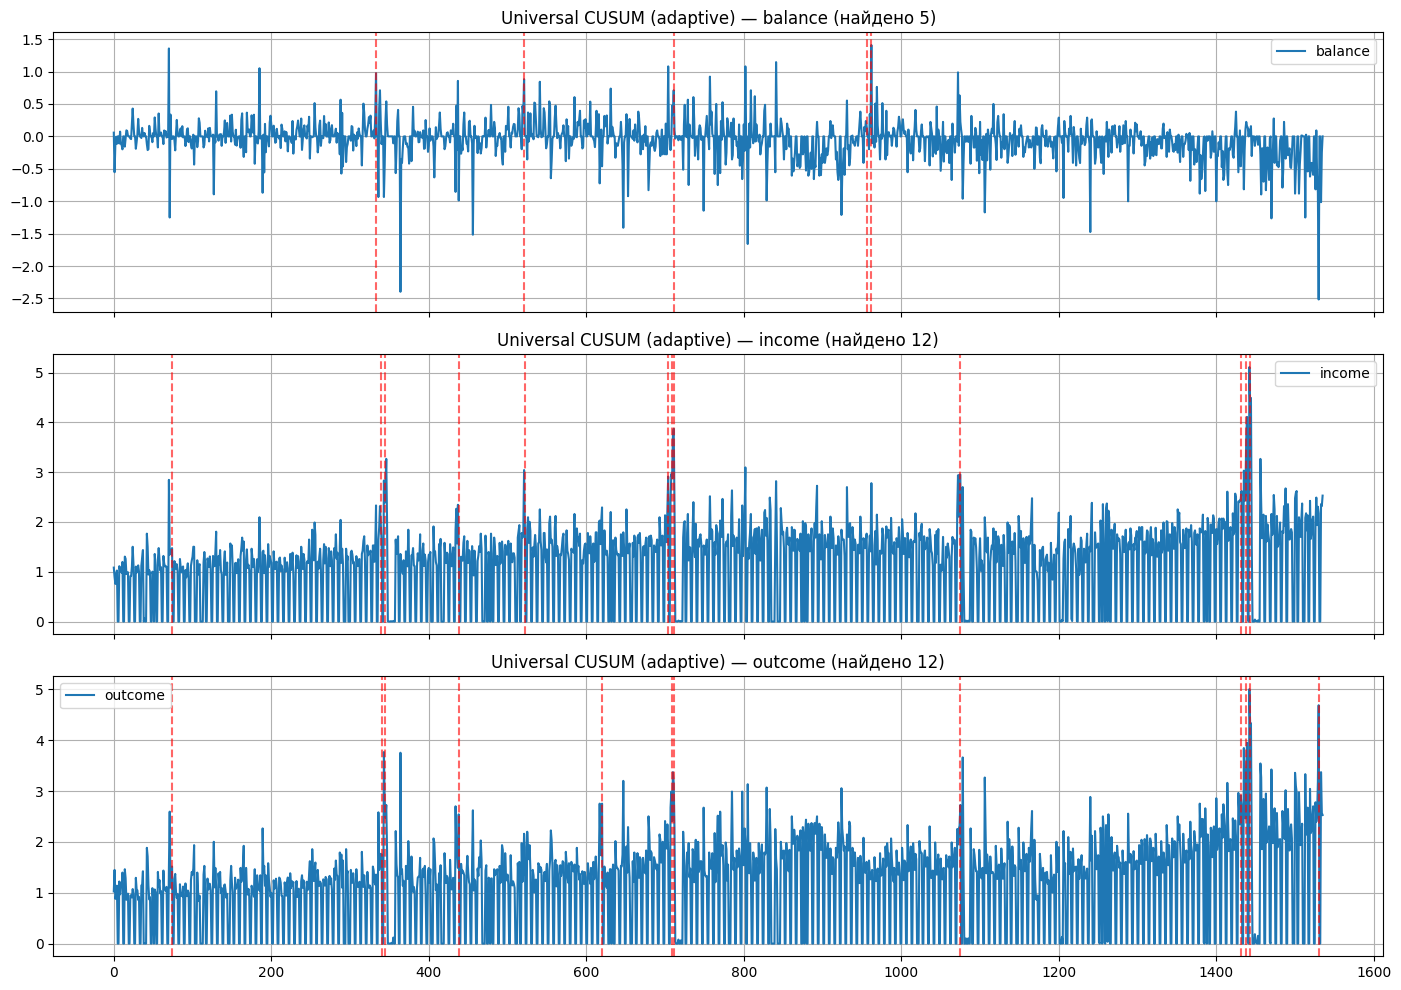

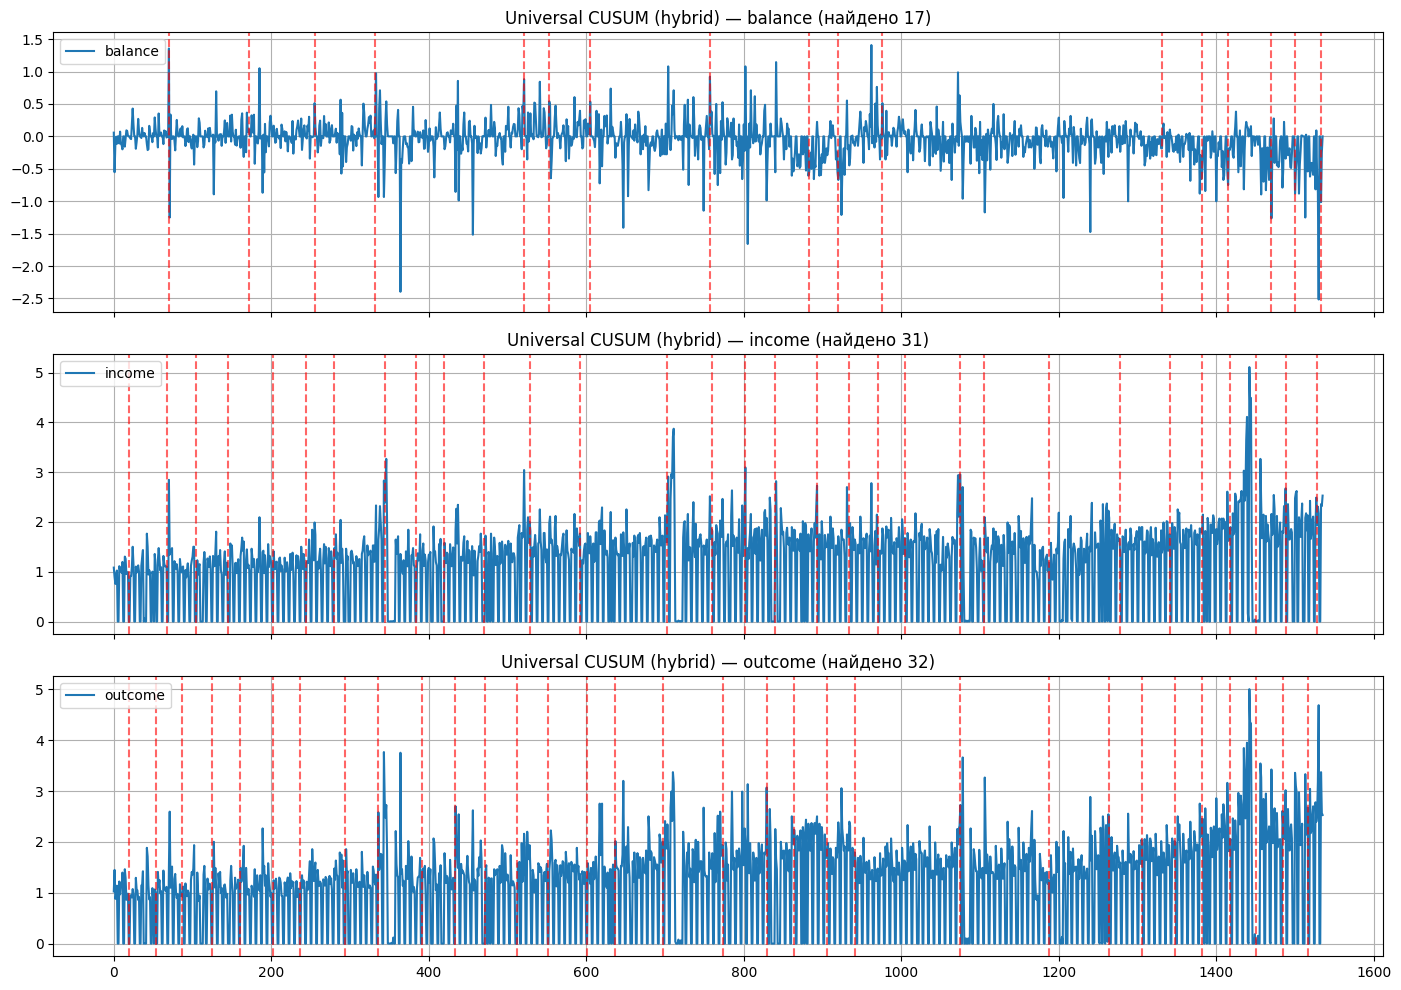

In [56]:
# === Пример использования ===


df = pd.read_csv('data/merged_dataset_with_lags_rollings.csv')
columns = ['balance', 'income', 'outcome']

    # Выбор режима
detector = UniversalCUSUMDetector(mode="adaptive", threshold=1.0,min_distance=1)
#detector = UniversalCUSUMDetector(mode="hybrid", threshold=8.0,min_distance=1,alpha=0.02, beta=0.02, mean_diff=0.3)

fig, axes = plt.subplots(len(columns), 1, figsize=(14, 10), sharex=True)
for i, col in enumerate(columns):
    series = df[col]
    cps = detector.detect(series)
    axes[i].plot(series.values, label=col)
    for cp in cps:
        axes[i].axvline(cp, color='red', linestyle='--', alpha=0.6)
    axes[i].set_title(f'Universal CUSUM ({detector.mode}) — {col} (найдено {len(cps)})')
    axes[i].legend()
    axes[i].grid(True)
    detector.reset()

plt.tight_layout()
plt.show()


# === Пример использования ===


df = pd.read_csv('data/merged_dataset_with_lags_rollings.csv')
columns = ['balance', 'income', 'outcome']

    # Выбор режима
#detector = UniversalCUSUMDetector(mode="adaptive", threshold=1.0,min_distance=1)
detector = UniversalCUSUMDetector(mode="hybrid", threshold=5.0,min_distance=30,alpha=0.02, beta=0.02, mean_diff=0.3)

fig, axes = plt.subplots(len(columns), 1, figsize=(14, 10), sharex=True)
for i, col in enumerate(columns):
    series = df[col]
    cps = detector.detect(series)
    axes[i].plot(series.values, label=col)
    for cp in cps:
        axes[i].axvline(cp, color='red', linestyle='--', alpha=0.6)
    axes[i].set_title(f'Universal CUSUM ({detector.mode}) — {col} (найдено {len(cps)})')
    axes[i].legend()
    axes[i].grid(True)
    detector.reset()

plt.tight_layout()
plt.show()


### Выводы по поведению детектора

- **Hybrid режим** находит много точек разладки, включая небольшие отклонения даже при незначительных колебаниях ряда.
- **Adaptive режим** реагирует только на более крупные и устойчивые изменения поведения данных.


### Преимущества и недостатки каждого режима

**Hybrid режим:**

Преимущества:
- Очень высокая чувствительность к сдвигам среднего значения.
- Позволяет оперативно отлавливать локальные скачки или провалы в данных, которые могут быть связаны с важными для ликвидности банка событиями.
- Хорошо работает в условиях, когда изменения происходят резко и имеют короткий характер.

Недостатки:
- Генерирует большое количество срабатываний, включая шумовые сигналы.
- Требует более внимательной фильтрации и настройки параметров (например, `threshold`, `min_distance`), чтобы избежать перегрузки процессом ручного управления.
- Может приводить к избыточному числу внеплановых переключений на ручной режим, что увеличит нагрузку на операторов.

**Adaptive режим:**

Преимущества:
- Выявляет только действительно значимые изменения, фильтруя краткосрочный шум.
- Обеспечивает более стабильную работу пайплайна без излишних переключений на ручное вмешательство.
- Лучше подходит для процессов с относительно плавной динамикой изменений, характерных для типичного банковского потока ликвидности вне кризисных ситуаций.

Недостатки:
- Менее чувствителен к коротким и резким аномалиям. При резком внешнем шоке (например, неожиданном изменении макроэкономических условий) может среагировать с запозданием.
- Требует аккуратной калибровки параметров адаптации (`alpha`, `beta`) под разные стадии рыночного цикла.

### Сценарии применения

- В обычные стабильные периоды, когда в потоках ликвидности отсутствуют резкие изменения, целесообразно применять **адаптивный режим**. Он позволяет избегать ложных срабатываний и обеспечивает более надёжную работу системы без лишних переключений на ручное управление.

- В случае наступления кризисных или высоковолатильных периодов на рынке имеет смысл заранее планировать переход на **гибридный режим** для более плотного контроля за процессами.

Таким образом, выбор режима должен быть увязан с бизнес-контекстом: адаптивный режим — для спокойных условий, гибридный — для периодов повышенного риска и нестабильности.


# **Блок 8. Онлайн запуск и автоматическое переобучение** 


[I 2025-04-28 01:25:12,479] A new study created in memory with name: no-name-ed05e70a-c55d-40e8-a354-42549bc92088


Первичное обучение до 2020-07-01
Обучение на 1262 примерах...


Best trial: 0. Best value: 0.257798: 100%|██████████| 1/1 [00:01<00:00,  1.95s/it]


[I 2025-04-28 01:25:14,428] Trial 0 finished with value: 0.25779847581573145 and parameters: {'n_estimators': 144, 'learning_rate': 0.28570714885887566, 'max_depth': 21}. Best is trial 0 with value: 0.25779847581573145.
2020-07-01 | MAE: 0.2718, mae_cust: 0.2718, calculate_add_margin_vectorized: 0.0000, normalized_add_margin: 0.1145, delta_pnl: -0.0012
2020-07-02 | MAE: 0.6179, mae_cust: 0.6179, calculate_add_margin_vectorized: 0.0000, normalized_add_margin: 0.0131, delta_pnl: -0.0015
2020-07-03 | MAE: 0.0848, mae_cust: 0.0848, calculate_add_margin_vectorized: 0.0000, normalized_add_margin: 0.0027, delta_pnl: -0.0004
2020-07-04 | MAE: 0.1766, mae_cust: 0.1766, calculate_add_margin_vectorized: 0.0000, normalized_add_margin: 2419309652.1298, delta_pnl: -0.0009
2020-07-05 | MAE: 0.0619, mae_cust: 0.0619, calculate_add_margin_vectorized: 0.0000, normalized_add_margin: 847793547.3748, delta_pnl: -0.0003
2020-07-06 | MAE: 0.0462, mae_cust: 0.0462, calculate_add_margin_vectorized: 0.0000, nor

[I 2025-04-28 01:25:22,497] A new study created in memory with name: no-name-50a27ffb-fbf1-41a4-b20e-52aab52750ca
Best trial: 0. Best value: 0.277818: 100%|██████████| 1/1 [00:01<00:00,  1.82s/it]


[I 2025-04-28 01:25:24,319] Trial 0 finished with value: 0.27781823483079593 and parameters: {'n_estimators': 144, 'learning_rate': 0.28570714885887566, 'max_depth': 21}. Best is trial 0 with value: 0.27781823483079593.
2020-12-29 | MAE: 0.0070, mae_cust: 0.0070, calculate_add_margin_vectorized: -0.0000, normalized_add_margin: -0.0031, delta_pnl: -0.0001
2020-12-30 | MAE: 0.2832, mae_cust: 0.2832, calculate_add_margin_vectorized: -0.0000, normalized_add_margin: -0.0092, delta_pnl: -0.5356
2020-12-31 | MAE: 0.3784, mae_cust: 0.3784, calculate_add_margin_vectorized: 0.0000, normalized_add_margin: 0.0032, delta_pnl: -0.0004
2021-01-01 | MAE: 0.0440, mae_cust: 0.0440, calculate_add_margin_vectorized: 0.0000, normalized_add_margin: 573154014.5908, delta_pnl: -0.0002
2021-01-02 | MAE: 0.1292, mae_cust: 0.1292, calculate_add_margin_vectorized: 0.0000, normalized_add_margin: 1681237572.7628, delta_pnl: -0.0006
2021-01-03 | MAE: 0.1897, mae_cust: 0.1897, calculate_add_margin_vectorized: 0.0000,

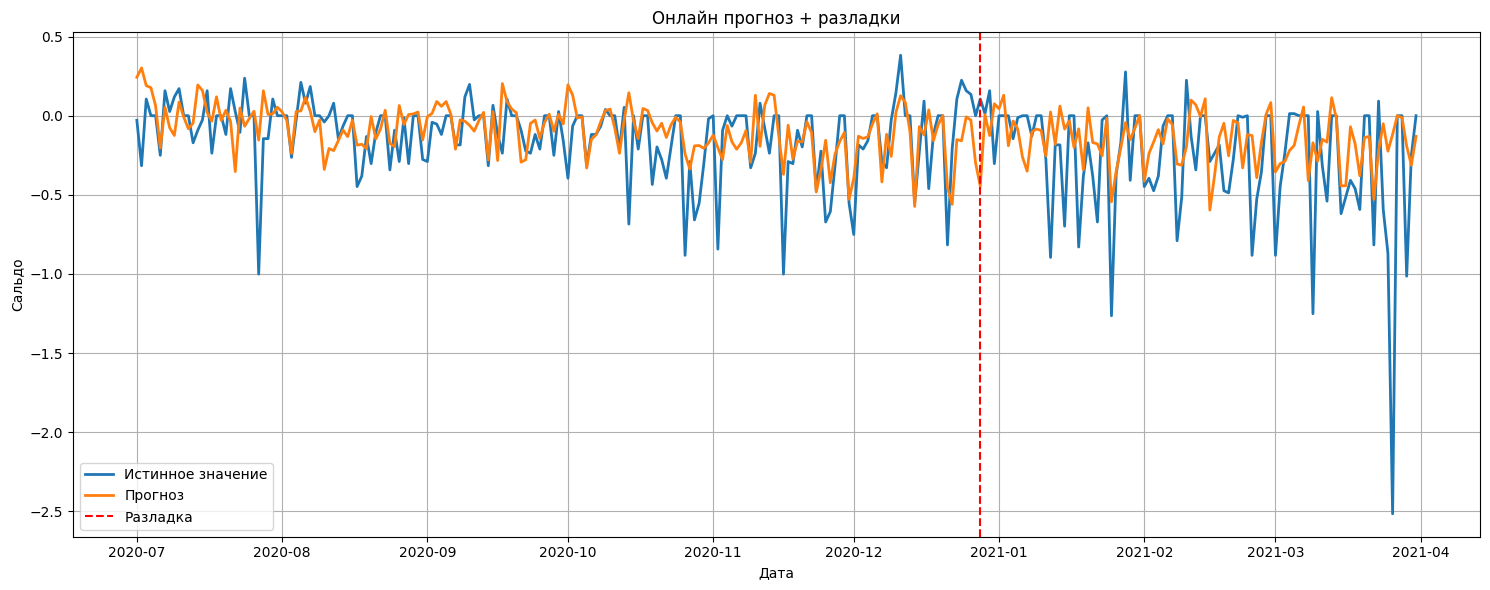

In [11]:
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

class ModelPipeline:
    def __init__(
        self,
        models_config: dict,
        n_splits: int = 3,
        feature_selector_top_k: int = 20,
        n_trials: int = 10,
        metric_func=mean_absolute_error,
        optuna_direction: str = "minimize",
        use_optuna: bool = True,
    ):
        self.models_config = models_config
        self.n_splits = n_splits
        self.top_k = feature_selector_top_k
        self.n_trials = n_trials
        self.metric_func = metric_func
        self.optuna_direction = optuna_direction
        self.use_optuna = use_optuna
        self.best_params = {}

    def tune_model(self, model_name, X, y, key_rate):
        def objective(trial):
            model_cls, param_space = self.models_config[model_name]
            params = {k: v(trial) for k, v in param_space.items()}
            tscv = TimeSeriesSplit(n_splits=self.n_splits)

            fold_losses = []

            for train_idx, val_idx in tscv.split(X):
                X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
                y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
                rate_val = key_rate.iloc[val_idx]

                model = model_cls(**params)
                model.fit(X_tr, y_tr)
                y_pred = model.predict(X_val)

                fold_losses.append(self.metric_func(y_val, y_pred, rate_val))

            return np.mean(fold_losses)

        study = optuna.create_study(direction=self.optuna_direction, sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=self.n_trials, show_progress_bar=True)

        return study.best_params

    def run(self, X, y, key_rate, test_start_date, model_name, extra_metrics=None):
        if extra_metrics is None:
            extra_metrics = []

        results = []

        balance_reference = y[(y > 0) & (y.index >= test_start_date)].mean()

        X_train = X[X.index < test_start_date]
        X_test = X[X.index >= test_start_date]
        y_train = y.loc[X_train.index]
        y_test = y.loc[X_test.index]
        rate_train = key_rate.loc[X_train.index]
        rate_test = key_rate.loc[X_test.index]

        if model_name not in self.models_config:
            raise ValueError(f"Модель '{model_name}' не найдена в models_config.")

        if self.use_optuna:
            print(f"\n🔧 Калибровка модели: {model_name}")
            best_params = self.tune_model(model_name, X_train, y_train, rate_train)
        else:
            print(f"\n Обучение {model_name} без тюнинга (параметры по умолчанию)")
            best_params = {}  # Просто пустой словарь

        self.best_params[model_name] = best_params

        model_cls = self.models_config[model_name][0]
        selector_model = model_cls(**best_params)
        selector_model.fit(X_train, y_train)
        top_features = self._select_top_features(selector_model, X_train)
        print(f"Топ-{self.top_k} признаков для {model_name}: {top_features}")

        if X_test.empty:
            print("Нет тестовых данных. Обучение модели без теста.")
            model = model_cls(**best_params)
            model.fit(X_train[top_features], y_train)
            return None

        # делаем финальное обучение только по топовым признакам
        model = model_cls(**best_params, verbose=0)
        model.fit(X_train[top_features], y_train)
        y_pred = model.predict(X_test[top_features])

        results.append(
            self._evaluate(model_name, y_test, y_pred, rate_test, balance_reference, extra_metrics)
        )

        self._plot(y_test, y_pred, model_name)

        return pd.DataFrame(results)

    # остальное без изменений


    def _select_top_features(self, model, X):
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
        elif hasattr(model, "coef_"):
            importances = np.abs(model.coef_)
        else:
            raise ValueError("Model does not support feature importance or coef_.")
        
        top_indices = np.argsort(importances)[::-1][:self.top_k]
        return list(X.columns[top_indices])

    def _evaluate(self, name, y_true, y_pred, rate, balance_ref, extra_metrics):
        result = {
            "Model": name,
            "MAE": mean_absolute_error(y_true, y_pred),
            self.metric_func.__name__: self.metric_func(y_true, y_pred, rate),
        }
        for func in extra_metrics:
            result[func.__name__] = func(y_true, y_pred, rate)
        return result

    def _plot(self, y_true, y_pred, model_name):
        plt.figure(figsize=(15, 6))
        plt.plot(y_true.index, y_true.values, label="Истинное значение", linewidth=2)
        plt.plot(y_true.index, y_pred, label=f"Предсказание ({model_name})", linewidth=2)
        plt.title(f"Факт vs Прогноз для {model_name}")
        plt.xlabel("Дата")
        plt.ylabel("Сальдо")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def online_run(
        self,
        X,
        y,
        key_rate,
        start_date,
        detector: UniversalCUSUMDetector,
        retrain_every_n_sundays=2,
        reoptimize_every_m_sundays=4,
        model_name="LGBM",
        extra_metrics=None,
    ):
        if extra_metrics is None:
            extra_metrics = []
        
        self.daily_results = []
        self.daily_predictions = []
        self.change_points = []
        
        # --- Первичное обучение до start_date ---
        X_train = X[X.index < start_date]
        y_train = y[X.index < start_date]
        key_rate_train = key_rate[X.index < start_date]

        print(f"Первичное обучение до {start_date.date()}")
        self.use_optuna = True
        self._fit(X_train, y_train, key_rate_train, model_name)

        # --- Прогон в онлайн-режиме ---
        current_date = start_date
        sunday_counter = 0  # считаем воскресенья
        all_dates = X.index[X.index >= start_date]

        y_pred_total = []
        self.residuals = []


        while current_date <= all_dates[-1]:
            X_today = X.loc[[current_date]]
            y_today = y.loc[[current_date]]
            key_rate_today = key_rate.loc[[current_date]]
            
            # --- Предсказание ---
            y_pred_today = self.current_model.predict(X_today[self.current_top_features])[0]
            y_pred_total.append((current_date, y_today.values[0], y_pred_today))

            # --- Счёт метрик ---
            daily_result = self._evaluate(
                name=model_name,
                y_true=y_today,
                y_pred=np.array([y_pred_today]),
                rate=key_rate_today,
                balance_ref=1.0,  # не важен в онлайн метриках
                extra_metrics=extra_metrics
            )
            daily_result["date"] = current_date
            self.daily_results.append(daily_result)

            metrics_str = ', '.join(f"{k}: {v:.4f}" for k, v in daily_result.items() if k not in ['Model', 'date'])
            print(f"{current_date.date()} | {metrics_str}")

 
            # --- Детекция разладки ---
            # error_today = y_today.values[0] - y_pred_today
            # self.residuals.append(error_today)

            # detected_cps = detector.detect(pd.Series(self.residuals))

            error_today = y_today.values[0] - y_pred_today
            is_cp = detector.update(error_today)

            if is_cp:
                print(f"Разладка на {current_date.date()} — переобучение!")
                self.change_points.append(current_date)

                retrain_data = X[X.index <= current_date]
                retrain_target = y[y.index <= current_date]
                retrain_rate = key_rate[key_rate.index <= current_date]

                self.use_optuna = True
                self._fit(retrain_data, retrain_target, retrain_rate, model_name)
                sunday_counter = 0  # обнуляем счётчик воскресений


            # --- Переобучение по расписанию ---
            if current_date.weekday() == 6:  # Воскресенье
                sunday_counter += 1
                if sunday_counter % reoptimize_every_m_sundays == 0:
                    print(f"🔧 Регулярное переобучение с Optuna на {current_date.date()}")
                    retrain_data = X[X.index <= current_date]
                    retrain_target = y[y.index <= current_date]
                    retrain_rate = key_rate[key_rate.index <= current_date]

                    self.use_optuna = True
                    self._fit(retrain_data, retrain_target, retrain_rate, model_name)
                elif sunday_counter % retrain_every_n_sundays == 0:
                    print(f"Регулярное переобучение без Optuna на {current_date.date()}")
                    retrain_data = X[X.index <= current_date]
                    retrain_target = y[y.index <= current_date]
                    retrain_rate = key_rate[key_rate.index <= current_date]

                    self.use_optuna = False
                    self._fit(retrain_data, retrain_target, retrain_rate, model_name)

            # --- Переход к следующему дню ---
            idx = np.where(all_dates == current_date)[0][0]
            if idx + 1 >= len(all_dates):
                break
            current_date = all_dates[idx + 1]

        # --- Финальный расчёт ---
        daily_df = pd.DataFrame(self.daily_results)
        print("\nСредние метрики за период:")
        print(daily_df.select_dtypes(include=[np.number]).mean().T.round(10))

        # --- Построение графика ---
        self._plot_online(y_pred_total)

    def _fit(self, X_train, y_train, rate_train, model_name):
        print(f"Обучение на {len(X_train)} примерах...")

        if self.use_optuna:
            best_params = self.tune_model(model_name, X_train, y_train, rate_train)
        else:
            best_params = {}

        self.current_best_params = best_params
        model_cls = self.models_config[model_name][0]

        # --- обучение selector_model ---
        selector_model = model_cls(**best_params)
        if isinstance(selector_model, CatBoostRegressor):
            from catboost import Pool
            selector_pool = Pool(X_train, y_train)
            selector_model.fit(selector_pool,verbose=0)
        else:
            selector_model.fit(X_train, y_train)

        self.current_top_features = self._select_top_features(selector_model, X_train)

        # --- обучение финальной current_model ---
        self.current_model = model_cls(**best_params)
        if isinstance(self.current_model, CatBoostRegressor):
            from catboost import Pool
            train_pool = Pool(X_train[self.current_top_features], y_train)
            self.current_model.fit(train_pool, verbose=0)
        else:
            self.current_model.fit(X_train[self.current_top_features], y_train)


    def _plot_online(self, y_pred_total):
        dates, y_true, y_pred = zip(*y_pred_total)

        plt.figure(figsize=(15, 6))
        plt.plot(dates, y_true, label="Истинное значение", linewidth=2)
        plt.plot(dates, y_pred, label="Прогноз", linewidth=2)

        for cp in self.change_points:
            plt.axvline(x=cp, color='red', linestyle='--', label='Разладка' if cp == self.change_points[0] else "")

        plt.title("Онлайн прогноз + разладки")
        plt.xlabel("Дата")
        plt.ylabel("Сальдо")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


models_config = {
    "RandomForest": (
        RandomForestRegressor,
        {
            "n_estimators": lambda t: t.suggest_int("n_estimators", 100, 300),
            "max_depth": lambda t: t.suggest_int("max_depth", 5, 15),
            "min_samples_split": lambda t: t.suggest_int("min_samples_split", 2, 10),
            "random_state": lambda _: 42
        }
    ),
    "LGBM": (
        LGBMRegressor,
        {
            "n_estimators": lambda t: t.suggest_int("n_estimators", 50, 300),
            "learning_rate": lambda t: t.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": lambda t: t.suggest_int("max_depth", 10, 25),
            "random_state": lambda _: 42,
            "verbosity": lambda _: -1
        }
    )
    ,
    "CatBoost": (
        CatBoostRegressor,
        {
            "depth": lambda t: t.suggest_int("depth", 4, 10)
            ,
            "learning_rate": lambda t: t.suggest_float("learning_rate", 0.01, 0.3),
            "l2_leaf_reg": lambda t: t.suggest_float("l2_leaf_reg", 1, 10),
            "iterations": lambda _: 200,
            
            "verbose": lambda _: False,
            "random_seed": lambda _: 42,
            # "logging_level": lambda _: 'Silent'
        }

        
    )
}

df = pd.read_csv("data/merged_dataset_with_lags_rollings.csv", parse_dates=["date"]).set_index("date")
X = df.drop(columns=["balance", "income", "outcome"])
y = df["balance"]
key_rate = df["rate"]#.fillna(0.085)

# pipeline = ModelPipeline(
#     models_config,
#     metric_func=mae_cust,
#     optuna_direction="minimize",
#     use_optuna=False
# )

# results = pipeline.run(
#     X,
#     y,
#     key_rate,
#     test_start_date=X.index[int(len(X) * 0.8)],
#     model_name="LGBM",
#     extra_metrics=[ calculate_add_margin_vectorized]
# )

# print(results)


pipeline = ModelPipeline(
    models_config=models_config,
    metric_func=mae_cust,    # твоя кастомная метрика
    optuna_direction="minimize",
    n_trials=1, 
    use_optuna=False          # стартовое значение, будет переключаться внутри
)

detector = UniversalCUSUMDetector(
    mode="adaptive",
    threshold=1.0,
    drift=0.01,
    min_distance=20,
    alpha=0.02,
    beta=0.02,
    mean_diff=0.3
)
pipeline.online_run(
    X=X,
    y=y,
    key_rate=key_rate,

    start_date=pd.Timestamp('2020-07-01'),   #дата начала онлайн-прогноза
    detector=detector,
    retrain_every_n_sundays=4,               # каждые retrain_every_n_sundays воскресенья переобучение без Optuna
    reoptimize_every_m_sundays=70,             # каждые reoptimize_every_m_sundays воскресенья переобучение с Optuna
    model_name="LGBM",                        # какую модель использовать
    extra_metrics=[calculate_add_margin_vectorized, normalized_add_margin,delta_pnl]  #  доп. метрики 
)


,is_non_working_day,day_Friday,day_Saturday,day_Sunday,day_Monday,day_Tuesday,day_Wednesday,day_Thursday,month_January,month_February,...,6M_rollmean3,6M_rollstd3,6M_rollmin3,6M_rollmax3,6M_rollmed3,6M_rollmean7,6M_rollstd7,6M_rollmin7,6M_rollmax7,6M_rollmed7
date,,,,,,,,,,,,,,,,,,,,,
2017-01-16,0,0,0,0,1,0,0,0,1,0,...,10.590000,0.000000,10.59,10.59,10.59,10.588571,0.003780,10.58,10.59,10.59
2017-01-17,0,0,0,0,0,1,0,0,1,0,...,10.566667,0.040415,10.52,10.59,10.59,10.580000,0.026458,10.52,10.59,10.59
2017-01-18,0,0,0,0,0,0,1,0,1,0,...,10.536667,0.047258,10.50,10.59,10.52,10.567143,0.039461,10.50,10.59,10.59
2017-01-19,0,0,0,0,0,0,0,1,1,0,...,10.506667,0.011547,10.50,10.52,10.50,10.554286,0.045040,10.50,10.59,10.59
2017-01-20,0,1,0,0,0,0,0,0,1,0,...,10.500000,0.000000,10.50,10.50,10.50,10.541429,0.045981,10.50,10.59,10.52


[I 2025-04-27 23:39:43,118] A new study created in memory with name: no-name-54641190-d441-4584-8d46-911c17b5b95e



🔧 Калибровка модели: LGBM


Best trial: 0. Best value: 0.287225: 100%|██████████| 1/1 [00:01<00:00,  1.57s/it]


[I 2025-04-27 23:39:44,695] Trial 0 finished with value: 0.2872250433087576 and parameters: {'n_estimators': 144, 'learning_rate': 0.28570714885887566, 'max_depth': 21}. Best is trial 0 with value: 0.2872250433087576.
Топ-20 признаков для LGBM: ['balance_lag3', 'brent_cost_rollstd3', 'balance_rollstd3', 'ON_rollstd7', 'income_rollstd3', 'balance_rollstd7', 'gold_cost_rub_rollstd7', '3M_rollstd7', 'usd_rub_rollstd7', 'brent_cost_rollstd7', 'outcome_rollmean3', '2W_rollstd7', 'balance_lag1', '1W_rollstd7', 'balance_rollmean7', 'balance_rollmean3', 'usd_rub_rollstd3', '6M_rollstd7', 'gold_cost_rub_rollstd3', '1M_rollstd7']
Нет тестовых данных. Обучение модели без теста.
2020-09-01 — MAE: 0.33773, mae_cust: 0.33773, calculate_add_margin_vectorized: 0.00001, delta_pnl: -0.00024
2020-09-02 — MAE: 0.08063, mae_cust: 0.08063, calculate_add_margin_vectorized: 0.00001, delta_pnl: -0.00019
2020-09-03 — MAE: 0.27698, mae_cust: 0.27698, calculate_add_margin_vectorized: 0.00003, delta_pnl: -0.00112


...

2020-11-10 — MAE: 0.37818, mae_cust: 0.37818, calculate_add_margin_vectorized: 0.00002, delta_pnl: -0.00071
2020-11-11 — MAE: 0.20621, mae_cust: 0.20621, calculate_add_margin_vectorized: -0.00001, delta_pnl: -0.54303
2020-11-12 — MAE: 0.10464, mae_cust: 0.10464, calculate_add_margin_vectorized: 0.00000, delta_pnl: -0.00013
2020-11-13 — MAE: 0.36808, mae_cust: 0.36808, calculate_add_margin_vectorized: 0.00002, delta_pnl: -0.00066
2020-11-14 — MAE: 0.14007, mae_cust: 0.14007, calculate_add_margin_vectorized: 0.00002, delta_pnl: -0.00070
2020-11-15 — MAE: 0.05655, mae_cust: 0.05655, calculate_add_margin_vectorized: 0.00000, delta_pnl: -0.24091
2020-11-16 — MAE: 0.68535, mae_cust: 0.68535, calculate_add_margin_vectorized: 0.00000, delta_pnl: -1.34332
2020-11-17 — MAE: 0.09412, mae_cust: 0.09412, calculate_add_margin_vectorized: 0.00000, delta_pnl: -0.83306
2020-11-18 — MAE: 0.02079, mae_cust: 0.02079, calculate_add_margin_vectorized: 0.00000, delta_pnl: -1.20155
2020-11-19 — MAE: 0.07486, 

Best trial: 0. Best value: 0.320325: 100%|██████████| 1/1 [00:01<00:00,  1.73s/it]


[I 2025-04-27 23:39:52,983] Trial 0 finished with value: 0.3203253304587009 and parameters: {'n_estimators': 144, 'learning_rate': 0.28570714885887566, 'max_depth': 21}. Best is trial 0 with value: 0.3203253304587009.
Топ-20 признаков для LGBM: ['balance_lag3', 'brent_cost_rollstd3', 'balance_rollstd3', 'ON_rollstd7', 'gold_cost_rub_rollstd7', 'brent_cost_rollstd7', 'usd_rub_rollstd7', 'outcome_rollmean3', '3M_rollstd7', 'balance_rollmean3', 'gold_cost_rub_rollstd3', '1W_rollstd7', 'balance_rollstd7', 'usd_rub_rollstd3', '2W_rollstd7', 'balance_lag1', '1M_rollstd7', '6M_rollstd7', 'ON_rollstd3', 'income_rollstd7']
Нет тестовых данных. Обучение модели без теста.
2020-11-23 — MAE: 0.18978, mae_cust: 0.18978, calculate_add_margin_vectorized: 0.00000, delta_pnl: -2.81872
2020-11-24 — MAE: 0.00549, mae_cust: 0.00549, calculate_add_margin_vectorized: 0.00000, delta_pnl: -0.97268
2020-11-25 — MAE: 0.65657, mae_cust: 0.65657, calculate_add_margin_vectorized: 0.00000, delta_pnl: -0.06368
2020-1

[I 2025-04-27 23:40:01,513] A new study created in memory with name: no-name-b17ae090-280b-4cc9-add0-1cd3ef4f00ae
Best trial: 0. Best value: 0.361513: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]


[I 2025-04-27 23:40:02,863] Trial 0 finished with value: 0.3615125186145058 and parameters: {'n_estimators': 144, 'learning_rate': 0.28570714885887566, 'max_depth': 21}. Best is trial 0 with value: 0.3615125186145058.
Топ-20 признаков для LGBM: ['balance_lag3', 'balance_rollstd3', 'brent_cost_rollstd7', 'balance_rollmean7', 'brent_cost_rollstd3', 'ON_rollstd7', 'usd_rub_rollstd7', '6M_rollstd7', 'gold_cost_rub_rollstd7', 'balance_lag1', '2W_rollstd7', 'balance_rollmean3', '1W_rollstd7', 'outcome_rollmean3', '3M_rollstd7', 'balance_rollstd7', 'gold_cost_rub_rollstd3', 'usd_rub_rollstd3', '1M_rollstd7', 'income_rollstd3']
Нет тестовых данных. Обучение модели без теста.
2021-02-15 — MAE: 0.48574, mae_cust: 0.48574, calculate_add_margin_vectorized: 0.00000, delta_pnl: -3.29775
2021-02-16 — MAE: 0.03876, mae_cust: 0.03876, calculate_add_margin_vectorized: 0.00000, delta_pnl: -1.17025
2021-02-17 — MAE: 0.09297, mae_cust: 0.09297, calculate_add_margin_vectorized: 0.00000, delta_pnl: -0.38922


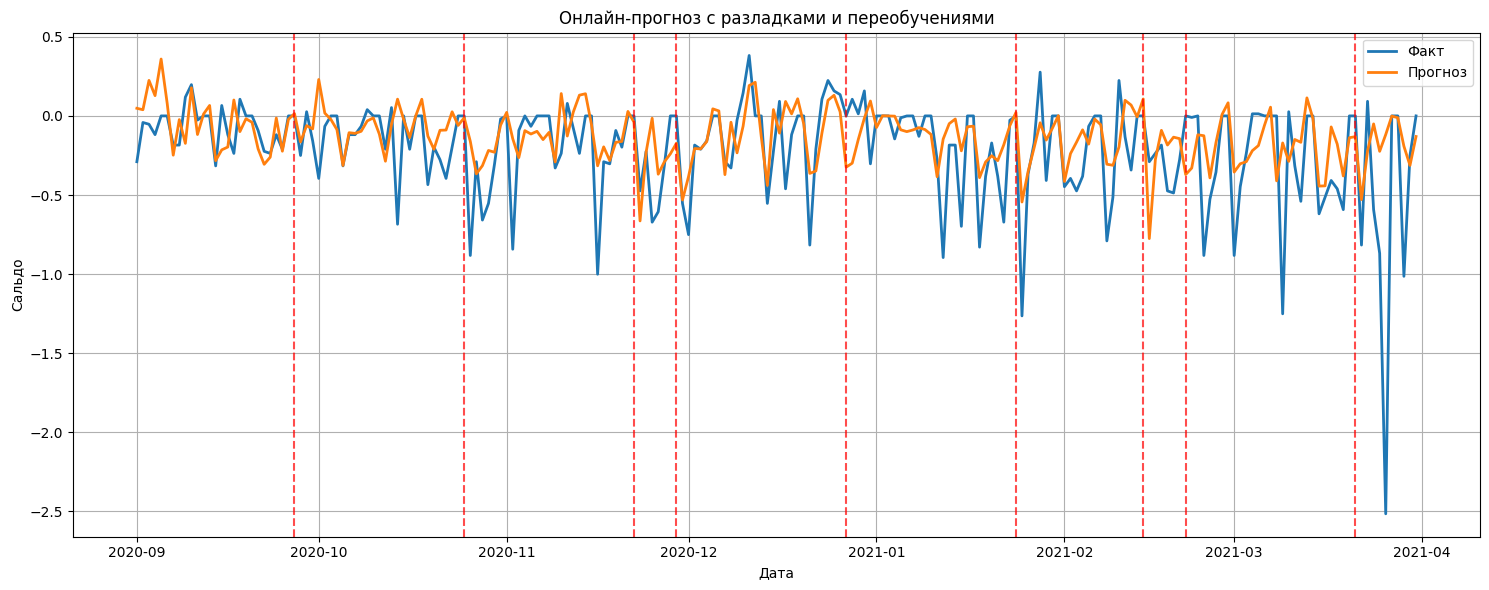

date                               2020-12-15 12:00:00
real                                         -0.209618
pred                                         -0.127593
MAE                                           0.194813
mae_cust                                      0.194813
calculate_add_margin_vectorized               0.000001
delta_pnl                                    -0.622996
dtype: object


In [ ]:
class OnlineForecastRunner:
    def __init__(self, model_pipeline, cusum_detector, retrain_every_n_weeks=4, optuna_every_m_weeks=12,extra_metrics=None):
        self.model_pipeline = model_pipeline
        self.detector = cusum_detector
        self.retrain_every_n_weeks = retrain_every_n_weeks
        self.optuna_every_m_weeks = optuna_every_m_weeks
        self.retrain_counter = 0
        self.optuna_retrain_counter = 0
        self.history = []
        self.change_points = []
        
        self.extra_metrics = extra_metrics or []


    def run(self, X, y, key_rate, start_date, model_name):
        dates = X.loc[X.index >= start_date].index
        current_X = X.loc[X.index < start_date].copy()
        current_y = y.loc[y.index < start_date].copy()
        current_rate = key_rate.loc[key_rate.index < start_date].copy()

        # Первичное обучение с Optuna
        self.model_pipeline.use_optuna = True
        self.model_pipeline.best_params = {}  # Сброс параметров
        self._train_model(current_X, current_y, current_rate, model_name)

        predictions = []
        reals = []

        for current_date in dates:
            X_today = X.loc[[current_date]]
            y_today = y.loc[[current_date]]
            rate_today = key_rate.loc[[current_date]]

            y_pred = self.model.predict(X_today[self.top_features])[0]
            metric_results = self._calculate_metrics(y_today, y_pred, rate_today)

            metrics_str = ", ".join(f"{k}: {v:.5f}" for k, v in metric_results.items())
            print(f"{current_date.date()} — {metrics_str}")

            # запись прогноза
            self.history.append({
                "date": current_date,
                "real": y_today.values[0],
                "pred": y_pred,
                **metric_results
            })

            predictions.append(y_pred)
            reals.append(y_today.values[0])

            # --- детекция разладки ---
            detected_cp = self.detector.detect(pd.Series([y_today.values[0] - y_pred]))
            if detected_cp:
                print(f"ыРазладка обнаружена на {current_date.date()}! Переобучение с Optuna.")
                self.model_pipeline.use_optuna = True
                self.model_pipeline.best_params = {}
                self._train_model(X.loc[X.index <= current_date], y.loc[y.index <= current_date], key_rate.loc[key_rate.index <= current_date], model_name)
                self.change_points.append(current_date)

            # --- еженедельные переобучения ---
            if current_date.weekday() == 6:  # Воскресенье
                self.retrain_counter += 1
                self.optuna_retrain_counter += 1

                if self.optuna_retrain_counter >= self.optuna_every_m_weeks:
                    print(f"Плановое переобучение с Optuna на {current_date.date()}.")
                    self.model_pipeline.use_optuna = True
                    self.model_pipeline.best_params = {}
                    self._train_model(X.loc[X.index <= current_date], y.loc[y.index <= current_date], key_rate.loc[key_rate.index <= current_date], model_name)
                    self.optuna_retrain_counter = 0
                    self.change_points.append(current_date)
                elif self.retrain_counter >= self.retrain_every_n_weeks:
                    print(f"Плановое переобучение без Optuna на {current_date.date()}.")
                    self.model_pipeline.use_optuna = False
                    self._train_model(X.loc[X.index <= current_date], y.loc[y.index <= current_date], key_rate.loc[key_rate.index <= current_date], model_name)
                    self.retrain_counter = 0
                    self.change_points.append(current_date)

        self._plot_results()
        return pd.DataFrame(self.history)

    def _train_model(self, X_train, y_train, rate_train, model_name):
        # Без разделения на тест, всё на обучении
        run_result = self.model_pipeline.run(
            X_train,
            y_train,
            rate_train,
            test_start_date=X_train.index[-1] + pd.Timedelta(days=1),
            model_name=model_name,
            extra_metrics=[]
        )
        # сохраняем модель
        self.model = self.model_pipeline.models_config[model_name][0](**self.model_pipeline.best_params[model_name])

        # здесь правильный способ получить топовые признаки:
        selector_model = self.model_pipeline.models_config[model_name][0](**self.model_pipeline.best_params[model_name])
        selector_model.fit(X_train, y_train)
        self.top_features = self.model_pipeline._select_top_features(selector_model, X_train)

        self.model.fit(X_train[self.top_features], y_train)


    def _calculate_metrics(self, y_true, y_pred, rate):
        res = {
            "MAE": mean_absolute_error(y_true, [y_pred]),
            self.model_pipeline.metric_func.__name__: self.model_pipeline.metric_func(y_true, [y_pred], rate),
        }
        #for func in self.model_pipeline.extra_metrics:
        for func in self.extra_metrics:

            res[func.__name__] = func(y_true, y_pred, rate)
        return res

    def _plot_results(self):
        df_history = pd.DataFrame(self.history)
        plt.figure(figsize=(15, 6))
        plt.plot(df_history["date"], df_history["real"], label="Факт", linewidth=2)
        plt.plot(df_history["date"], df_history["pred"], label="Прогноз", linewidth=2)
        for cp in self.change_points:
            plt.axvline(cp, color="red", linestyle="--", alpha=0.7)
        plt.xlabel("Дата")
        plt.ylabel("Сальдо")
        plt.title("Онлайн-прогноз с разладками и переобучениями")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

df = pd.read_csv("data/merged_dataset_with_lags_rollings.csv", parse_dates=["date"]).set_index("date")
X = df.drop(columns=["balance", "income", "outcome"])
y = df["balance"]
key_rate = df["rate"]#.fillna(0.085)

display(X.head())

pipeline = ModelPipeline(
    models_config,
    metric_func=mae_cust,  # или awmae
    optuna_direction="minimize",
    n_splits=2,
    n_trials=1,
    #extra_metrics=[calculate_add_margin_vectorized, delta_pnl]
)

runner = OnlineForecastRunner(
    model_pipeline=pipeline,
    cusum_detector=UniversalCUSUMDetector(mode="adaptive", threshold=5.0, drift=0.01),
    retrain_every_n_weeks=4,
    optuna_every_m_weeks=12,
    extra_metrics=[calculate_add_margin_vectorized, delta_pnl]
)

online_results = runner.run(
    X=X,
    y=y,
    key_rate=key_rate,
    start_date=pd.Timestamp("2020-09-01"),  # твоя стартовая дата
    model_name="LGBM"
)

print(online_results.mean())
